# Carregar dados pré-processados (da Parte 1)
Este notebook assume que você rodou a Parte 1 e gerou o cache com os DataFrames pré-processados.
Ele tenta carregar `m3_preprocess_cache.pkl` automaticamente.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

def find_diadema_dir(start: str | Path | None = None) -> Path:
    start_path = Path(start) if start is not None else Path.cwd()
    start_path = start_path.resolve()
    for p in [start_path, *start_path.parents]:
        candidate = p / 'Diadema'
        if candidate.exists() and candidate.is_dir():
            return candidate
    raise FileNotFoundError('Não encontrei a pasta Diadema a partir de: ' + str(start_path))

diadema_dir = find_diadema_dir()
cache_path = diadema_dir / 'm3_preprocess_cache.pkl'
if not cache_path.exists():
    raise FileNotFoundError(f'Cache não encontrado: {cache_path}. Rode a Parte 1 para gerar o arquivo.')

obj = pd.read_pickle(cache_path)

# Dados completos + split ligado/desligado (NÃO descartamos nada)
df_vel_m3_group = obj.get('df_vel_m3_group')
df_acc_m3_group = obj.get('df_acc_m3_group')
df_vel_m3_all = obj.get('df_vel_m3_all', df_vel_m3_group)
df_acc_m3_all = obj.get('df_acc_m3_all', df_acc_m3_group)
df_vel_m3_on = obj.get('df_vel_m3_on', df_vel_m3_group)
df_acc_m3_on = obj.get('df_acc_m3_on', df_acc_m3_group)
df_vel_m3_off = obj.get('df_vel_m3_off', pd.DataFrame())
df_acc_m3_off = obj.get('df_acc_m3_off', pd.DataFrame())
split_params = obj.get('split_params', {})

# Parte 2 trabalha SOMENTE com máquina ligada
df_vel_m3_group = df_vel_m3_on.copy()
df_acc_m3_group = df_acc_m3_on.copy()

print('OK: cache carregado')
print(f"Vel: all={len(df_vel_m3_all)}, on={len(df_vel_m3_on)}, off={len(df_vel_m3_off)}")
print(f"Acc: all={len(df_acc_m3_all)}, on={len(df_acc_m3_on)}, off={len(df_acc_m3_off)}")
if split_params:
    print('split_params:', split_params)

OK: cache carregado
Vel: all=6585, on=1138, off=5447
Acc: all=6585, on=1138, off=5447
split_params: {'noise_floor': 27.0, 'noise_floor_quantile': 0.02, 'min_on_points': 3, 'min_off_points': 3}


# IA sem label: detecção de anomalias (baseline forte)
Sem label de falha, o caminho mais prático é gerar um **score de anomalia** e inspecionar os maiores scores para validar com operação/manutenção.
Aqui vamos começar com **IsolationForest** (excelente baseline industrial para dados tabulares), e depois você pode evoluir para Autoencoder temporal se precisar.

In [26]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler

def build_anomaly_dataset(df_vel: pd.DataFrame, df_acc: pd.DataFrame) -> pd.DataFrame:
    """
    Monta um dataset único por minuto (inner join por time).
    Mantém somente colunas numéricas e remove linhas com NaN.
    """
    if "time" not in df_vel.columns or "time" not in df_acc.columns:
        raise ValueError("df_vel e df_acc precisam ter a coluna 'time'")

    vel = df_vel.copy()
    acc = df_acc.copy()

    # Prefixos para evitar colisão de nomes
    vel_cols = {c: f"vel_{c}" for c in vel.columns if c != "time"}
    acc_cols = {c: f"acc_{c}" for c in acc.columns if c != "time"}
    vel = vel.rename(columns=vel_cols)
    acc = acc.rename(columns=acc_cols)

    df = vel.merge(acc, on="time", how="inner").sort_values("time").reset_index(drop=True)

    feature_cols = [c for c in df.columns if c != "time"]
    # garantir numérico
    for c in feature_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # descarta linhas com qualquer NaN (como você pediu)
    df = df.dropna(subset=feature_cols).reset_index(drop=True)
    return df

# Usar apenas dados da máquina LIGADA
df_model = build_anomaly_dataset(df_vel_m3_on, df_acc_m3_on)
display(df_model.head())
print("Linhas para modelo (somente ligada):", len(df_model), "| colunas de features:", df_model.shape[1]-1)

,time,vel_maxtemp,vel_maxxpk,vel_maxypk,vel_maxzpk,vel_meanxrms,vel_meanyrms,vel_meanzrms,vel_is_on,acc_maxtemp,acc_maxxpk,acc_maxypk,acc_maxzpk,acc_meanxrms,acc_meanyrms,acc_meanzrms,acc_is_on
0,2025-12-12 00:41:00,23.0,32.0,44.0,72.0,7.000000,8.000000,10.833333,True,26.0,36.0,38.0,96.0,7.000000,8.454545,13.181818,True
1,2025-12-12 05:16:00,19.0,45.0,42.0,41.0,12.142858,12.142858,12.285714,True,19.0,28.0,40.0,66.0,7.000000,8.083333,10.833333,True
2,2025-12-12 05:21:00,18.0,52.0,45.0,62.0,14.142858,14.428572,16.857143,True,19.0,30.0,42.0,66.0,7.000000,8.083333,10.916667,True
3,2025-12-12 09:26:00,20.0,36.0,46.0,82.0,8.090909,9.272727,13.363636,True,19.0,46.0,39.0,51.0,16.000000,11.285714,14.857142,True
4,2025-12-12 09:31:00,18.0,42.0,44.0,47.0,12.142858,14.428572,14.428572,True,21.0,34.0,78.0,88.0,8.181818,9.600000,13.500000,True


Linhas para modelo (somente ligada): 1101 | colunas de features: 16


,time,anomaly_score
75,2025-12-12 15:26:00,0.035380
62,2025-12-12 14:21:00,0.033734
35,2025-12-12 12:06:00,0.021161
227,2025-12-15 12:01:00,0.014412
224,2025-12-15 11:46:00,0.012044
70,2025-12-12 15:01:00,0.009134
236,2025-12-15 12:46:00,0.006448
51,2025-12-12 13:26:00,0.005690
119,2025-12-13 11:36:00,0.003167
68,2025-12-12 14:51:00,0.001120


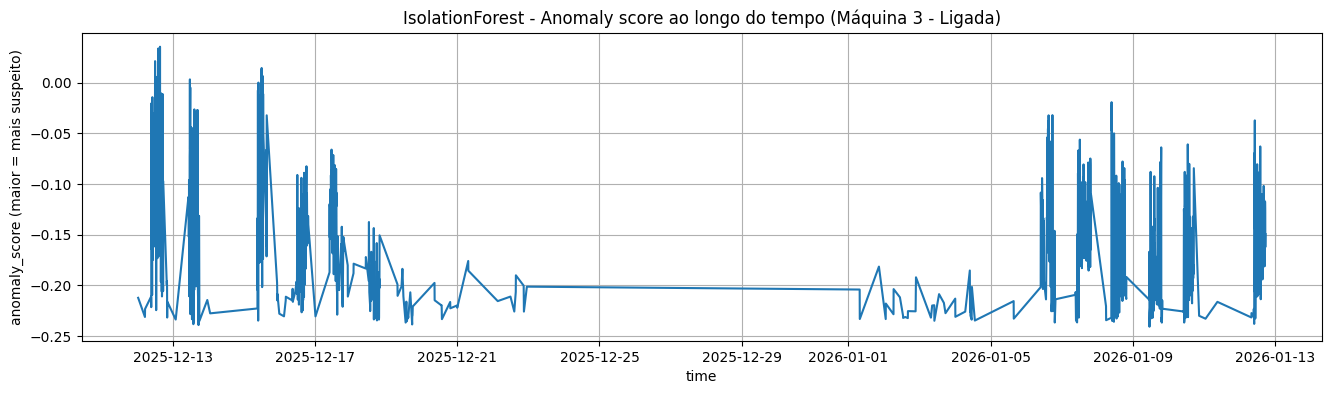

In [27]:
# Treino IsolationForest (baseline)
feature_cols = [c for c in df_model.columns if c != "time"]
X = df_model[feature_cols].astype("float32").values

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# Ajuste o contamination conforme expectativa de anomalia (ex.: 0.5% a 2%)
contamination = 0.01
iso = IsolationForest(
    n_estimators=400,
    contamination=contamination,
    random_state=42,
    n_jobs=-1,
)
iso.fit(X_scaled)

# score: quanto MAIOR, mais anômalo (invertendo decision_function)
df_scores = df_model[["time"]].copy()
df_scores["anomaly_score"] = -iso.decision_function(X_scaled)
df_scores = df_scores.sort_values("anomaly_score", ascending=False)

display(df_scores.head(20))

# Visual: score ao longo do tempo
df_plot = df_model[["time"]].copy()
df_plot["anomaly_score"] = -iso.decision_function(X_scaled)
df_plot = df_plot.sort_values("time")

plt.figure(figsize=(16, 4))
plt.plot(df_plot["time"], df_plot["anomaly_score"])
plt.title("IsolationForest - Anomaly score ao longo do tempo (Máquina 3 - Ligada)")
plt.xlabel("time")
plt.ylabel("anomaly_score (maior = mais suspeito)")
plt.grid(True)
plt.show()

Threshold (q=0.99): 0.000000


,time,anomaly_score,vel_maxtemp,vel_maxxpk,vel_maxypk,vel_maxzpk,vel_meanxrms,vel_meanyrms,vel_meanzrms,vel_is_on,acc_maxtemp,acc_maxxpk,acc_maxypk,acc_maxzpk,acc_meanxrms,acc_meanyrms,acc_meanzrms,acc_is_on
75,2025-12-12 15:26:00,0.035380,31.0,831.0,853.0,878.0,476.571442,433.857147,453.142853,True,30.0,485.0,976.0,899.0,174.857147,314.428558,316.000000,True
62,2025-12-12 14:21:00,0.033734,30.0,536.0,1406.0,752.0,104.583336,140.166672,114.500000,True,30.0,899.0,925.0,823.0,454.750000,422.125000,432.000000,True
35,2025-12-12 12:06:00,0.021161,23.0,754.0,693.0,802.0,412.285706,356.571442,411.857147,True,24.0,555.0,1068.0,817.0,220.285721,447.857147,397.428558,True
227,2025-12-15 12:01:00,0.014412,26.0,342.0,1236.0,392.0,82.181816,162.636368,69.454544,True,23.0,809.0,854.0,856.0,454.250000,484.285706,427.375000,True
224,2025-12-15 11:46:00,0.012044,25.0,332.0,1136.0,348.0,81.727272,154.272720,66.636360,True,23.0,874.0,974.0,818.0,452.375000,456.500000,428.875000,True
70,2025-12-12 15:01:00,0.009134,31.0,580.0,1218.0,664.0,112.166664,142.500000,120.750000,True,31.0,784.0,834.0,809.0,425.500000,397.375000,404.125000,True
236,2025-12-15 12:46:00,0.006448,27.0,338.0,1032.0,434.0,81.545456,164.636368,70.272728,True,25.0,837.0,905.0,830.0,464.375000,492.625000,437.250000,True
51,2025-12-12 13:26:00,0.005690,29.0,658.0,1116.0,624.0,118.416664,145.833328,120.666664,True,28.0,830.0,849.0,821.0,447.125000,408.375000,430.571442,True
119,2025-12-13 11:36:00,0.003167,21.0,410.0,1182.0,408.0,81.909088,166.454544,69.363640,True,18.0,831.0,847.0,798.0,404.625000,429.500000,401.500000,True
68,2025-12-12 14:51:00,0.001120,31.0,233.0,584.0,468.0,93.142860,283.714294,245.571426,True,30.0,792.0,803.0,826.0,436.875000,413.000000,416.375000,True


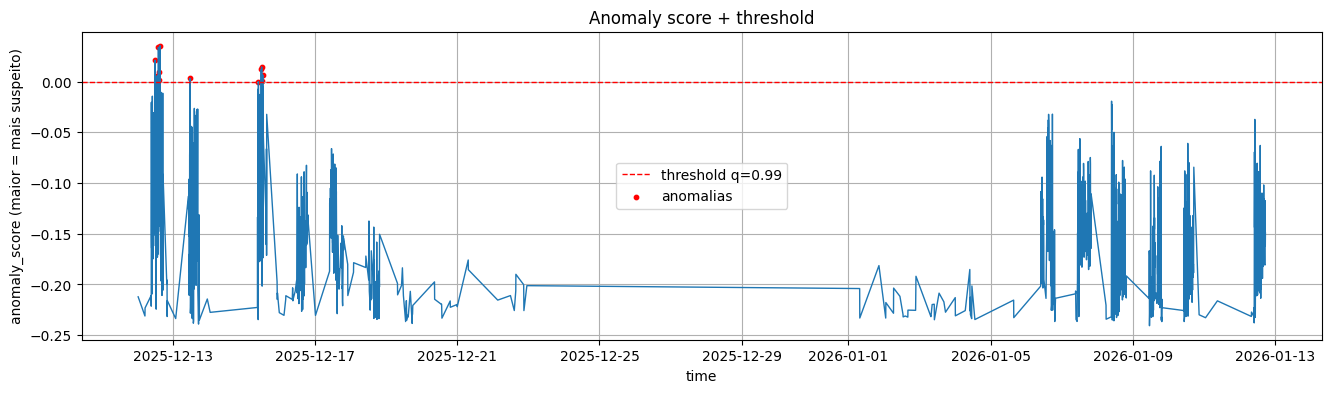

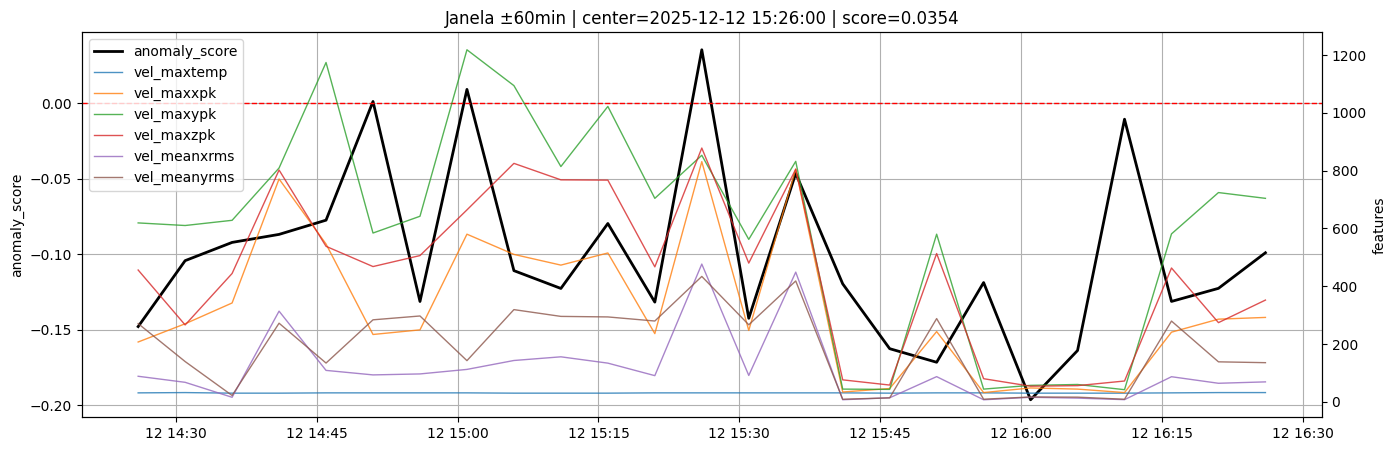

In [28]:
# Inspeção: top eventos e janela ao redor
df_scored = df_model.copy()
df_scored["anomaly_score"] = -iso.decision_function(X_scaled)
df_scored = df_scored.sort_values("time").reset_index(drop=True)

# Threshold por quantil (ex.: top 1% mais anômalos)
q = 0.99
threshold = float(df_scored["anomaly_score"].quantile(q))
print(f"Threshold (q={q}): {threshold:.6f}")

top_n = 20
top_events = df_scored.sort_values("anomaly_score", ascending=False).head(top_n)
display(top_events[["time", "anomaly_score"] + feature_cols].head(10))

# Score com marcação acima do limiar
plt.figure(figsize=(16, 4))
plt.plot(df_scored["time"], df_scored["anomaly_score"], linewidth=1)
plt.axhline(threshold, color="red", linestyle="--", linewidth=1, label=f"threshold q={q}")
mask = df_scored["anomaly_score"] >= threshold
plt.scatter(df_scored.loc[mask, "time"], df_scored.loc[mask, "anomaly_score"], s=10, color="red", label="anomalias")
plt.title("Anomaly score + threshold")
plt.xlabel("time")
plt.ylabel("anomaly_score (maior = mais suspeito)")
plt.legend()
plt.grid(True)
plt.show()

def plot_event_window(center_time: pd.Timestamp, minutes: int = 60):
    start = center_time - pd.Timedelta(minutes=minutes)
    end = center_time + pd.Timedelta(minutes=minutes)
    w = df_scored[(df_scored["time"] >= start) & (df_scored["time"] <= end)].copy()
    if w.empty:
        print("Sem dados na janela")
        return
    w = w.sort_values("time")

    score_center_series = df_scored.loc[df_scored["time"] == center_time, "anomaly_score"]
    score_center = float(score_center_series.iloc[0]) if len(score_center_series) else float(w["anomaly_score"].max())

    fig, ax1 = plt.subplots(figsize=(16, 5))
    ax1.plot(w["time"], w["anomaly_score"], color="black", linewidth=2, label="anomaly_score")
    ax1.axhline(threshold, color="red", linestyle="--", linewidth=1)
    ax1.set_ylabel("anomaly_score")
    ax1.grid(True)

    # Plota algumas features (máximos e RMS) para entender o que estourou
    cols_to_plot = [c for c in feature_cols if ("max" in c or "rms" in c or "temp" in c)]
    cols_to_plot = cols_to_plot[:6]  # limita para não virar bagunça
    ax2 = ax1.twinx()
    for c in cols_to_plot:
        ax2.plot(w["time"], w[c], linewidth=1, alpha=0.8, label=c)
    ax2.set_ylabel("features")

    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc="upper left")
    plt.title(f"Janela ±{minutes}min | center={center_time} | score={score_center:.4f}")
    plt.show()

# Exemplo: plota a janela do evento mais anômalo
plot_event_window(pd.to_datetime(top_events.iloc[0]["time"]))

# Calibração + Alertas (2 níveis / debounce)
Agora vamos:
1) calibrar thresholds (por quantil) e ver quantos alertas isso gera por *dia ativo*;
2) criar **2 níveis**:
   - **casual/warning**: threshold mais baixo (mais sensível)
   - **crítico**: threshold mais alto (mais conservador)
3) agrupar pontos anômalos em **eventos** (debounce/merge por janela) e criar uma tabela de alertas com resumo das variáveis.

Tempo ativo estimado: 3.56 dias


,q,threshold,alerts,alerts_per_active_day
0,0.999,0.032477,0,0.000000
1,0.998,0.019811,0,0.000000
2,0.995,0.007791,0,0.000000
3,0.990,0.000000,2,0.561404
4,0.985,-0.010892,2,0.561404
5,0.980,-0.015060,4,1.122807


Warning  q=0.99 | threshold=0.000000
Critical q=0.995 | threshold=0.007791
Total de alertas (warning): 2
Total de alertas (critical): 0
Alertas warning por dia ativo (aprox.): 0.5614035087719298
Alertas critical por dia ativo (aprox.): 0.0


""


,start_time,end_time,peak_time,max_score,points,duration_min,mean_vel_maxtemp,max_vel_maxtemp,mean_vel_maxxpk,max_vel_maxxpk,...,mean_acc_maxypk,max_acc_maxypk,mean_acc_maxzpk,max_acc_maxzpk,mean_acc_meanxrms,max_acc_meanxrms,mean_acc_meanyrms,max_acc_meanyrms,mean_acc_meanzrms,max_acc_meanzrms
0,2025-12-12 14:21:00,2025-12-12 15:26:00,2025-12-12 15:26:00,0.035380,4,65.0,30.642857,32.0,449.928558,831.0,...,844.928589,1192.0,640.928589,899.0,175.966232,454.75,245.235153,422.125000,219.029694,432.000
1,2025-12-15 11:46:00,2025-12-15 12:06:00,2025-12-15 12:01:00,0.014412,3,20.0,24.200001,26.0,570.400024,845.0,...,872.200012,1154.0,640.000000,856.0,235.798798,454.25,341.245209,484.285706,283.626190,428.875


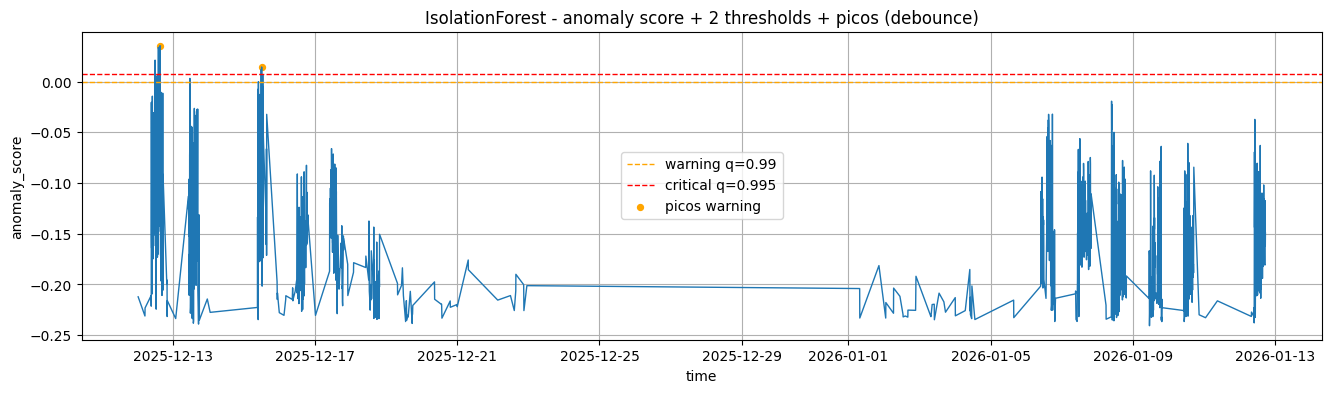

In [29]:
def build_alerts(
    df_scored: pd.DataFrame,
    feature_cols: list[str],
    threshold: float,
    merge_gap_minutes: int = 30,
    min_points: int = 3,
    summary_cols: list[str] | None = None,
    ) -> pd.DataFrame:
    """
    Converte pontos anômalos em eventos (alertas) com debounce via merge_gap_minutes.

    - df_scored precisa ter: time, anomaly_score e colunas feature_cols
    - threshold: pontos com score >= threshold viram candidatos
    - merge_gap_minutes: junta pontos se a distância entre timestamps <= merge_gap_minutes
    - min_points: descarta eventos muito curtos (ruído)
    - summary_cols: colunas a resumir (default: subset de max/rms/temp)
    """
    if df_scored.empty:
        return pd.DataFrame()

    df = df_scored.sort_values("time").reset_index(drop=True).copy()
    if summary_cols is None:
        summary_cols = [c for c in feature_cols if ("max" in c or "rms" in c or "temp" in c)]
        if not summary_cols:
            summary_cols = feature_cols[:]

    candidates = df[df["anomaly_score"] >= threshold].copy()
    if candidates.empty:
        return pd.DataFrame(columns=["start_time", "end_time", "peak_time", "max_score", "points"])

    candidates = candidates.sort_values("time").reset_index(drop=True)
    gap = pd.Timedelta(minutes=merge_gap_minutes)
    dt = candidates["time"].diff()
    event_id = (dt.isna() | (dt > gap)).cumsum()
    candidates["event_id"] = event_id

    events = []
    for eid, g in candidates.groupby("event_id", sort=True):
        if len(g) < min_points:
            continue
        start_time = g["time"].iloc[0]
        end_time = g["time"].iloc[-1]
        peak_idx = g["anomaly_score"].idxmax()
        peak_time = candidates.loc[peak_idx, "time"]
        max_score = float(candidates.loc[peak_idx, "anomaly_score"])

        window = df[(df["time"] >= start_time) & (df["time"] <= end_time)]
        row = {
            "start_time": start_time,
            "end_time": end_time,
            "peak_time": peak_time,
            "max_score": max_score,
            "points": int(len(g)),
            "duration_min": float((end_time - start_time) / pd.Timedelta(minutes=1)),
        }
        for c in summary_cols:
            row[f"mean_{c}"] = float(window[c].mean())
            row[f"max_{c}"] = float(window[c].max())
        events.append(row)

    out = pd.DataFrame(events)
    if out.empty:
        return out
    return out.sort_values(["max_score", "start_time"], ascending=[False, True]).reset_index(drop=True)

def estimate_active_days(df_scored: pd.DataFrame) -> float:
    """
    Estima tempo ATIVO (dias) ignorando períodos desligado.
    Heurística: considera "ativo" quando a diferença entre amostras é <= 2x o passo mediano.
    """
    if df_scored.empty:
        return 0.0
    t = df_scored.sort_values("time")["time"]
    dt = t.diff().dropna()
    if dt.empty:
        return 0.0
    step = dt.median()
    active_dt = dt.where(dt <= 2 * step, pd.Timedelta(0))
    active_seconds = active_dt.dt.total_seconds().sum()
    return float(active_seconds / 86400.0)

def evaluate_quantiles(
    df_scored: pd.DataFrame,
    feature_cols: list[str],
    q_list: list[float],
    merge_gap_minutes: int = 30,
    min_points: int = 3,
    active_days: float | None = None,
    ) -> pd.DataFrame:
    """
    Retorna quantos alertas saem por quantil e normaliza por tempo ativo (ignora downtime).
    """
    df = df_scored.sort_values("time")
    if active_days is None:
        active_days = estimate_active_days(df)
    active_days = max(active_days, 1e-9)
    rows = []
    for q in q_list:
        thr = float(df["anomaly_score"].quantile(q))
        alerts_tmp = build_alerts(
            df_scored=df,
            feature_cols=feature_cols,
            threshold=thr,
            merge_gap_minutes=merge_gap_minutes,
            min_points=min_points,
        )
        n_alerts = int(len(alerts_tmp))
        rows.append({
            "q": q,
            "threshold": thr,
            "alerts": n_alerts,
            "alerts_per_active_day": n_alerts / active_days,
        })
    return pd.DataFrame(rows).sort_values("q", ascending=False).reset_index(drop=True)

# 1) Calibração rápida de quantis (sem "forçar" alertas/dia)
active_days = estimate_active_days(df_scored)
print(f"Tempo ativo estimado: {active_days:.2f} dias")

q_list = [0.98, 0.985, 0.99, 0.995, 0.998, 0.999]
calib = evaluate_quantiles(
    df_scored,
    feature_cols,
    q_list=q_list,
    merge_gap_minutes=30,
    min_points=3,
    active_days=active_days,
 )
display(calib)

# 2) Dois níveis de alerta
q_warning = 0.99
q_critical = 0.995

threshold_warning = float(df_scored["anomaly_score"].quantile(q_warning))
threshold_critical = float(df_scored["anomaly_score"].quantile(q_critical))
print(f"Warning  q={q_warning} | threshold={threshold_warning:.6f}")
print(f"Critical q={q_critical} | threshold={threshold_critical:.6f}")

alerts_warning = build_alerts(
    df_scored=df_scored,
    feature_cols=feature_cols,
    threshold=threshold_warning,
    merge_gap_minutes=30,
    min_points=3,
 )
alerts_critical = build_alerts(
    df_scored=df_scored,
    feature_cols=feature_cols,
    threshold=threshold_critical,
    merge_gap_minutes=30,
    min_points=3,
 )

print("Total de alertas (warning):", len(alerts_warning))
print("Total de alertas (critical):", len(alerts_critical))
if active_days > 0:
    print("Alertas warning por dia ativo (aprox.):", len(alerts_warning) / active_days)
    print("Alertas critical por dia ativo (aprox.):", len(alerts_critical) / active_days)

display(alerts_critical.head(20))
display(alerts_warning.head(20))

# Visual: score + thresholds + picos
plt.figure(figsize=(16, 4))
plt.plot(df_scored["time"], df_scored["anomaly_score"], linewidth=1)
plt.axhline(threshold_warning, color="orange", linestyle="--", linewidth=1, label=f"warning q={q_warning}")
plt.axhline(threshold_critical, color="red", linestyle="--", linewidth=1, label=f"critical q={q_critical}")
if len(alerts_warning):
    plt.scatter(alerts_warning["peak_time"], alerts_warning["max_score"], color="orange", s=18, label="picos warning")
if len(alerts_critical):
    plt.scatter(alerts_critical["peak_time"], alerts_critical["max_score"], color="red", s=28, label="picos critical")
plt.title("IsolationForest - anomaly score + 2 thresholds + picos (debounce)")
plt.xlabel("time")
plt.ylabel("anomaly_score")
plt.legend()
plt.grid(True)
plt.show()

# Autoencoder (baseline) via MLPRegressor (sem labels)
A ideia aqui é reconstruir as features (após scaling) e usar o **erro de reconstrução** como score de anomalia.
Isso funciona como um *autoencoder* simples, sem precisar instalar TensorFlow/PyTorch.

AE/MLPRegressor - score (recon_mse) stats:


count    1101.000000
mean        0.004344
std         0.004606
min         0.000099
50%         0.003085
90%         0.009513
95%         0.012259
99%         0.024369
99.5%       0.026750
99.9%       0.036111
max         0.050122
Name: anomaly_score, dtype: float64

Tempo ativo estimado (AE): 3.56 dias


,q,threshold,alerts,alerts_per_active_day
0,0.999,0.036111,0,0.000000
1,0.998,0.033930,0,0.000000
2,0.995,0.026750,0,0.000000
3,0.990,0.024369,0,0.000000
4,0.985,0.018895,1,0.280702
5,0.980,0.017291,2,0.561404


AE Warning  q=0.99 | threshold=0.024369
AE Critical q=0.995 | threshold=0.026750
Total de alertas AE (warning): 0
Total de alertas AE (critical): 0
Alertas AE warning por dia ativo (aprox.): 0.0
Alertas AE critical por dia ativo (aprox.): 0.0


""


""


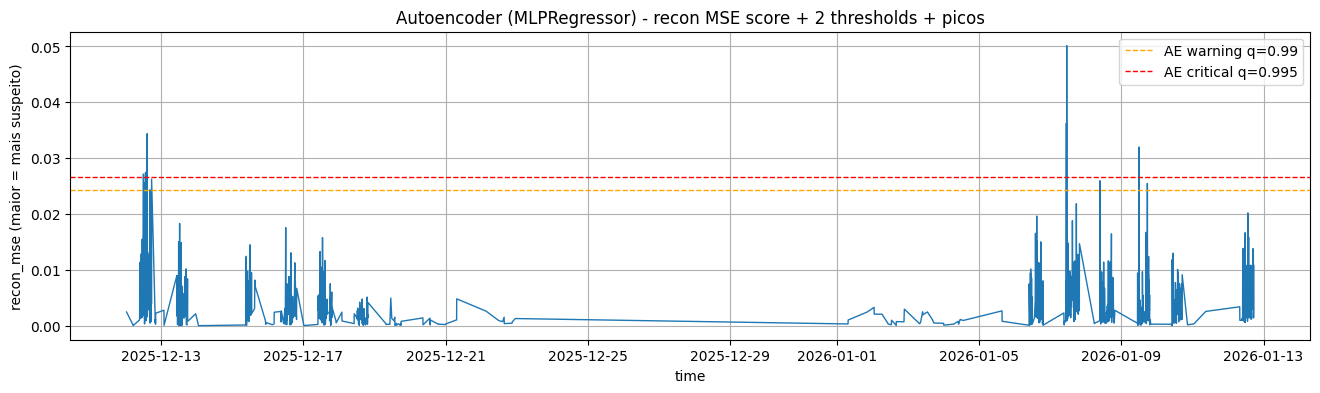

In [30]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
import warnings
from sklearn.exceptions import ConvergenceWarning

# Dataset (mesmo df_model / feature_cols)
feature_cols = [c for c in df_model.columns if c != "time"]
X = df_model[feature_cols].astype("float32").values

# Split temporal simples (treina no passado, testa no futuro)
n = len(df_model)
cut = int(n * 0.8)
X_train_raw = X[:cut]
X_all_raw = X

scaler_ae = RobustScaler()
X_train = scaler_ae.fit_transform(X_train_raw)
X_all = scaler_ae.transform(X_all_raw)

# "Autoencoder" tabular: aprende a reconstruir X (targets = X)
# Bottleneck pequeno força o modelo a capturar padrão normal e errar no estranho.
ae = MLPRegressor(
    hidden_layer_sizes=(32, 8, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=400,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42,
    verbose=False,
 )

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    ae.fit(X_train, X_train)

# Reconstrução e score por erro
X_hat = ae.predict(X_all)
recon_mse = np.mean((X_all - X_hat) ** 2, axis=1).astype("float32")

df_scored_ae = df_model.copy()
df_scored_ae["anomaly_score"] = recon_mse
df_scored_ae = df_scored_ae.sort_values("time").reset_index(drop=True)

print("AE/MLPRegressor - score (recon_mse) stats:")
display(df_scored_ae["anomaly_score"].describe(percentiles=[0.9, 0.95, 0.99, 0.995, 0.999]))

# Calibração + 2 níveis (mesmas funções build_alerts/evaluate_quantiles)
active_days_ae = estimate_active_days(df_scored_ae)
print(f"Tempo ativo estimado (AE): {active_days_ae:.2f} dias")

q_list_ae = [0.98, 0.985, 0.99, 0.995, 0.998, 0.999]
calib_ae = evaluate_quantiles(
    df_scored_ae,
    feature_cols,
    q_list=q_list_ae,
    merge_gap_minutes=30,
    min_points=3,
    active_days=active_days_ae,
 )
display(calib_ae)

q_warning_ae = 0.99
q_critical_ae = 0.995
thr_warning_ae = float(df_scored_ae["anomaly_score"].quantile(q_warning_ae))
thr_critical_ae = float(df_scored_ae["anomaly_score"].quantile(q_critical_ae))
print(f"AE Warning  q={q_warning_ae} | threshold={thr_warning_ae:.6f}")
print(f"AE Critical q={q_critical_ae} | threshold={thr_critical_ae:.6f}")

alerts_warning_ae = build_alerts(
    df_scored=df_scored_ae,
    feature_cols=feature_cols,
    threshold=thr_warning_ae,
    merge_gap_minutes=30,
    min_points=3,
 )
alerts_critical_ae = build_alerts(
    df_scored=df_scored_ae,
    feature_cols=feature_cols,
    threshold=thr_critical_ae,
    merge_gap_minutes=30,
    min_points=3,
 )

print("Total de alertas AE (warning):", len(alerts_warning_ae))
print("Total de alertas AE (critical):", len(alerts_critical_ae))
if active_days_ae > 0:
    print("Alertas AE warning por dia ativo (aprox.):", len(alerts_warning_ae) / active_days_ae)
    print("Alertas AE critical por dia ativo (aprox.):", len(alerts_critical_ae) / active_days_ae)

display(alerts_critical_ae.head(20))
display(alerts_warning_ae.head(20))

# Visual: score + thresholds + picos
plt.figure(figsize=(16, 4))
plt.plot(df_scored_ae["time"], df_scored_ae["anomaly_score"], linewidth=1)
plt.axhline(thr_warning_ae, color="orange", linestyle="--", linewidth=1, label=f"AE warning q={q_warning_ae}")
plt.axhline(thr_critical_ae, color="red", linestyle="--", linewidth=1, label=f"AE critical q={q_critical_ae}")
if len(alerts_warning_ae):
    plt.scatter(alerts_warning_ae["peak_time"], alerts_warning_ae["max_score"], color="orange", s=18, label="AE picos warning")
if len(alerts_critical_ae):
    plt.scatter(alerts_critical_ae["peak_time"], alerts_critical_ae["max_score"], color="red", s=28, label="AE picos critical")
plt.title("Autoencoder (MLPRegressor) - recon MSE score + 2 thresholds + picos")
plt.xlabel("time")
plt.ylabel("recon_mse (maior = mais suspeito)")
plt.legend()
plt.grid(True)
plt.show()

# Comparação: IsolationForest vs Autoencoder (MLPRegressor)
Nesta seção vamos comparar os dois modelos com métricas objetivas:
- correlação dos scores ao longo do tempo (Pearson/Spearman)
- overlap de alertas (picos) dentro de uma tolerância de tempo
- taxa de alertas por dia ativo para warning/crítico

Correlação (scores brutos):
  Pearson : 0.536
  Spearman: 0.698
Correlação (scores em percentil/rank):
  Pearson : 0.698
  Spearman: 0.698


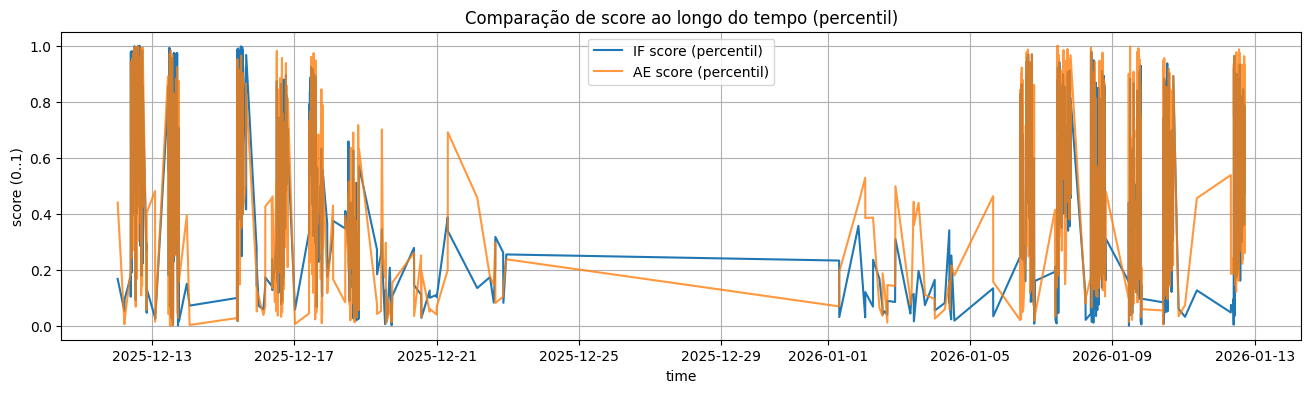

,A,B,tol_min,A_peaks,B_peaks,matched,jaccard
0,IF critical,AE critical,30,0,0,0,1.0
1,IF warning,AE warning,30,2,0,0,0.0


,model,level,alerts,active_days,alerts_per_active_day
1,IsolationForest,critical,0,3.5625,0.000000
3,Autoencoder(MLP),critical,0,3.5625,0.000000
2,Autoencoder(MLP),warning,0,3.5625,0.000000
0,IsolationForest,warning,2,3.5625,0.561404


Picos críticos IF:


""


Picos críticos AE:


""


Nenhum crítico casado entre IF e AE dentro da tolerância.


In [31]:
# Requer que você tenha rodado as seções acima: df_scored (IF), df_scored_ae (AE), alerts_*
tol_minutes = 30  # tolerância para considerar "mesmo evento" entre modelos
tol = pd.Timedelta(minutes=tol_minutes)

# 1) Alinhar scores por time e calcular correlação
cmp = (
    df_scored[["time", "anomaly_score"]].rename(columns={"anomaly_score": "score_if"})
    .merge(
        df_scored_ae[["time", "anomaly_score"]].rename(columns={"anomaly_score": "score_ae"}),
        on="time", how="inner"
    )
    .sort_values("time")
    .reset_index(drop=True)
 )

# Normalizações úteis para plot (percentil/rank)
cmp["if_pct"] = cmp["score_if"].rank(pct=True)
cmp["ae_pct"] = cmp["score_ae"].rank(pct=True)

pearson_raw = float(cmp[["score_if", "score_ae"]].corr(method="pearson").iloc[0, 1])
spearman_raw = float(cmp[["score_if", "score_ae"]].corr(method="spearman").iloc[0, 1])
pearson_pct = float(cmp[["if_pct", "ae_pct"]].corr(method="pearson").iloc[0, 1])
spearman_pct = float(cmp[["if_pct", "ae_pct"]].corr(method="spearman").iloc[0, 1])

print("Correlação (scores brutos):")
print(f"  Pearson : {pearson_raw:.3f}")
print(f"  Spearman: {spearman_raw:.3f}")
print("Correlação (scores em percentil/rank):")
print(f"  Pearson : {pearson_pct:.3f}")
print(f"  Spearman: {spearman_pct:.3f}")

plt.figure(figsize=(16, 4))
plt.plot(cmp["time"], cmp["if_pct"], label="IF score (percentil)")
plt.plot(cmp["time"], cmp["ae_pct"], label="AE score (percentil)", alpha=0.8)
plt.title("Comparação de score ao longo do tempo (percentil)")
plt.xlabel("time")
plt.ylabel("score (0..1)")
plt.grid(True)
plt.legend()
plt.show()

# 2) Overlap de alertas (picos) entre os modelos
def match_peak_times(a_times: list[pd.Timestamp], b_times: list[pd.Timestamp], tol: pd.Timedelta):
    """Retorna pares casados (a->b) com matching guloso por proximidade."""
    a_sorted = sorted(pd.to_datetime(a_times))
    b_sorted = sorted(pd.to_datetime(b_times))
    used_b = set()
    pairs = []
    for ta in a_sorted:
        best_j = None
        best_dt = None
        for j, tb in enumerate(b_sorted):
            if j in used_b:
                continue
            d = abs(tb - ta)
            if d <= tol and (best_dt is None or d < best_dt):
                best_dt = d
                best_j = j
        if best_j is not None:
            used_b.add(best_j)
            pairs.append((ta, b_sorted[best_j], best_dt))
    return pairs

def overlap_report(alerts_a: pd.DataFrame, alerts_b: pd.DataFrame, label_a: str, label_b: str):
    a_times = [] if alerts_a is None or alerts_a.empty else list(alerts_a["peak_time"])
    b_times = [] if alerts_b is None or alerts_b.empty else list(alerts_b["peak_time"])
    pairs = match_peak_times(a_times, b_times, tol=tol)
    matched_a = len(pairs)
    matched_b = len(pairs)
    denom = (len(a_times) + len(b_times) - len(pairs))
    jaccard = (len(pairs) / denom) if denom else 1.0
    return {
        "A": label_a,
        "B": label_b,
        "tol_min": tol_minutes,
        "A_peaks": len(a_times),
        "B_peaks": len(b_times),
        "matched": len(pairs),
        "jaccard": jaccard,
    }, pairs

rep_crit, pairs_crit = overlap_report(alerts_critical, alerts_critical_ae, "IF critical", "AE critical")
rep_warn, pairs_warn = overlap_report(alerts_warning, alerts_warning_ae, "IF warning", "AE warning")

display(pd.DataFrame([rep_crit, rep_warn]))

# 3) Tabela de comparação de taxas (por dia ativo)
summary = pd.DataFrame([
    {"model": "IsolationForest", "level": "warning", "alerts": int(len(alerts_warning)), "active_days": float(active_days), "alerts_per_active_day": float(len(alerts_warning) / max(active_days, 1e-9))},
    {"model": "IsolationForest", "level": "critical", "alerts": int(len(alerts_critical)), "active_days": float(active_days), "alerts_per_active_day": float(len(alerts_critical) / max(active_days, 1e-9))},
    {"model": "Autoencoder(MLP)", "level": "warning", "alerts": int(len(alerts_warning_ae)), "active_days": float(active_days_ae), "alerts_per_active_day": float(len(alerts_warning_ae) / max(active_days_ae, 1e-9))},
    {"model": "Autoencoder(MLP)", "level": "critical", "alerts": int(len(alerts_critical_ae)), "active_days": float(active_days_ae), "alerts_per_active_day": float(len(alerts_critical_ae) / max(active_days_ae, 1e-9))},
])
display(summary.sort_values(["level", "alerts_per_active_day"]))

# 4) Listar eventos críticos (picos) para inspeção rápida
print("Picos críticos IF:")
display(alerts_critical[["peak_time", "max_score", "points", "duration_min"]].head(20) if len(alerts_critical) else alerts_critical)
print("Picos críticos AE:")
display(alerts_critical_ae[["peak_time", "max_score", "points", "duration_min"]].head(20) if len(alerts_critical_ae) else alerts_critical_ae)

if pairs_crit:
    print("Críticos casados (IF ↔ AE) dentro da tolerância:")
    display(pd.DataFrame([{
        "if_peak": a,
        "ae_peak": b,
        "delta_min": float(dt / pd.Timedelta(minutes=1)),
    } for (a, b, dt) in pairs_crit]).sort_values("delta_min"))
else:
    print("Nenhum crítico casado entre IF e AE dentro da tolerância.")

# Alerta combinado (IF + AE)
Aqui criamos um alerta operacional mais robusto combinando os dois modelos:
- **critical_combined**: só quando **IsolationForest e Autoencoder** dão crítico no mesmo período (± tolerância)
- **warning_combined**: união dos warnings dos dois modelos (com deduplicação por tempo)
- **final_alerts**: critical_combined (prioridade) + warning_combined que não colide com crítico

In [32]:
# Requer: alerts_warning, alerts_critical, alerts_warning_ae, alerts_critical_ae
tol_minutes = 30
tol = pd.Timedelta(minutes=tol_minutes)

def _safe_list_times(df: pd.DataFrame, col: str) -> list[pd.Timestamp]:
    if df is None or df.empty or col not in df.columns:
        return []
    return list(pd.to_datetime(df[col]))

def match_events_by_peak(
    alerts_a: pd.DataFrame,
    alerts_b: pd.DataFrame,
    tol: pd.Timedelta,
    label_a: str = "A",
    label_b: str = "B",
 ) -> pd.DataFrame:
    """Casa eventos por proximidade do peak_time (matching guloso)."""
    a_times = _safe_list_times(alerts_a, "peak_time")
    b_times = _safe_list_times(alerts_b, "peak_time")
    a_sorted = sorted(a_times)
    b_sorted = sorted(b_times)
    used_b: set[int] = set()
    rows = []
    for ta in a_sorted:
        best_j = None
        best_dt = None
        for j, tb in enumerate(b_sorted):
            if j in used_b:
                continue
            d = abs(tb - ta)
            if d <= tol and (best_dt is None or d < best_dt):
                best_dt = d
                best_j = j
        if best_j is None:
            continue
        used_b.add(best_j)
        tb = b_sorted[best_j]
        ra = alerts_a.loc[pd.to_datetime(alerts_a["peak_time"]) == ta].head(1)
        rb = alerts_b.loc[pd.to_datetime(alerts_b["peak_time"]) == tb].head(1)
        # fallback seguro (caso existam duplicatas no mesmo peak_time)
        start_time = min(
            pd.to_datetime(ra["start_time"].iloc[0]) if len(ra) else ta,
            pd.to_datetime(rb["start_time"].iloc[0]) if len(rb) else tb,
        )
        end_time = max(
            pd.to_datetime(ra["end_time"].iloc[0]) if len(ra) else ta,
            pd.to_datetime(rb["end_time"].iloc[0]) if len(rb) else tb,
        )
        rows.append({
            "start_time": start_time,
            "end_time": end_time,
            "peak_time": ta,
            f"{label_a}_peak_time": ta,
            f"{label_b}_peak_time": tb,
            f"{label_a}_max_score": float(ra["max_score"].iloc[0]) if len(ra) else np.nan,
            f"{label_b}_max_score": float(rb["max_score"].iloc[0]) if len(rb) else np.nan,
            f"{label_a}_points": int(ra["points"].iloc[0]) if len(ra) else 0,
            f"{label_b}_points": int(rb["points"].iloc[0]) if len(rb) else 0,
            "delta_min": float(best_dt / pd.Timedelta(minutes=1)) if best_dt is not None else np.nan,
            "support": f"{label_a}+{label_b}",
            "duration_min": float((end_time - start_time) / pd.Timedelta(minutes=1)),
        })
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    return out.sort_values("peak_time").reset_index(drop=True)

def union_events(
    alerts_if: pd.DataFrame,
    alerts_ae: pd.DataFrame,
    tol: pd.Timedelta,
    ) -> pd.DataFrame:
    """União de eventos por peak_time com deduplicação em clusters por tolerância."""
    a = alerts_if.copy() if alerts_if is not None and len(alerts_if) else pd.DataFrame()
    b = alerts_ae.copy() if alerts_ae is not None and len(alerts_ae) else pd.DataFrame()
    if len(a):
        a["model"] = "IF"
    if len(b):
        b["model"] = "AE"
    peaks = pd.concat([a, b], ignore_index=True)
    if peaks.empty:
        return peaks
    peaks["peak_time"] = pd.to_datetime(peaks["peak_time"])
    peaks["start_time"] = pd.to_datetime(peaks["start_time"])
    peaks["end_time"] = pd.to_datetime(peaks["end_time"])
    peaks = peaks.sort_values("peak_time").reset_index(drop=True)
    dt = peaks["peak_time"].diff()
    cluster_id = (dt.isna() | (dt > tol)).cumsum()
    peaks["cluster_id"] = cluster_id
    out_rows = []
    for cid, g in peaks.groupby("cluster_id", sort=True):
        start_time = g["start_time"].min()
        end_time = g["end_time"].max()
        # Se existir AE e IF no cluster, marca BOTH
        support = "+".join(sorted(g["model"].unique()))
        # Escolhe um peak representativo (o maior score dentro do cluster, mas sem comparar escalas entre modelos)
        # Heurística: pega o maior score *dentro de cada modelo* e, se houver 2 modelos, escolhe o mais raro (maior percentil)
        g2 = g.copy()
        g2["score_pct"] = 0.0
        for m in g2["model"].unique():
            idx = g2["model"] == m
            # rank por modelo
            g2.loc[idx, "score_pct"] = g2.loc[idx, "max_score"].rank(pct=True)
        peak_row = g2.sort_values(["score_pct", "peak_time"], ascending=[False, True]).iloc[0]
        out_rows.append({
            "start_time": start_time,
            "end_time": end_time,
            "peak_time": pd.to_datetime(peak_row["peak_time"]),
            "support": support,
            "if_max_score": float(g[g["model"] == "IF"]["max_score"].max()) if (g["model"] == "IF").any() else np.nan,
            "ae_max_score": float(g[g["model"] == "AE"]["max_score"].max()) if (g["model"] == "AE").any() else np.nan,
            "duration_min": float((end_time - start_time) / pd.Timedelta(minutes=1)),
            "n_events": int(len(g)),
        })
    out = pd.DataFrame(out_rows).sort_values("peak_time").reset_index(drop=True)
    return out

# 1) Critical combinado = interseção (IF critical ∩ AE critical)
critical_combined = match_events_by_peak(
    alerts_a=alerts_critical,
    alerts_b=alerts_critical_ae,
    tol=tol,
    label_a="if",
    label_b="ae",
)
if len(critical_combined):
    critical_combined["level"] = "critical"

# 2) Warning combinado = união (IF warning ∪ AE warning) com deduplicação por tempo
warning_combined = union_events(alerts_warning, alerts_warning_ae, tol=tol)
if len(warning_combined):
    warning_combined["level"] = "warning"

# 3) Final = críticos + warnings que não colidem com críticos
def drop_overlapping_warnings(warn_df: pd.DataFrame, crit_df: pd.DataFrame, tol: pd.Timedelta) -> pd.DataFrame:
    if warn_df is None or warn_df.empty:
        return pd.DataFrame()
    if crit_df is None or crit_df.empty:
        return warn_df.reset_index(drop=True)
    w = warn_df.copy()
    w["peak_time"] = pd.to_datetime(w["peak_time"])
    crit_times = list(pd.to_datetime(crit_df["peak_time"]))
    keep = []
    for t in w["peak_time"]:
        collide = any(abs(t - tc) <= tol for tc in crit_times)
        keep.append(not collide)
    return w.loc[keep].reset_index(drop=True)

warning_only = drop_overlapping_warnings(warning_combined, critical_combined, tol=tol)

final_alerts = pd.concat([critical_combined, warning_only], ignore_index=True)
if not final_alerts.empty:
    final_alerts = final_alerts.sort_values(["level", "peak_time"], ascending=[True, True]).reset_index(drop=True)

print(f"Tolerância de combinação: ±{tol_minutes} min")
print("critical_combined:", len(critical_combined))
print("warning_combined (dedup):", len(warning_combined))
print("warning_only (sem colidir com crítico):", len(warning_only))
print("final_alerts:", len(final_alerts))

print("\nCríticos combinados (IF+AE):")
display(critical_combined if len(critical_combined) else pd.DataFrame({"msg": ["Nenhum crítico com consenso IF+AE."]}))

print("\nWarnings combinados (IF ou AE):")
display(warning_combined.head(30) if len(warning_combined) else pd.DataFrame({"msg": ["Nenhum warning."]}))

print("\nFinal (operacional):")
display(final_alerts.head(50) if len(final_alerts) else pd.DataFrame({"msg": ["Nenhum alerta final."]}))

Tolerância de combinação: ±30 min
critical_combined: 0
warning_combined (dedup): 2
warning_only (sem colidir com crítico): 2
final_alerts: 2

Críticos combinados (IF+AE):


,msg
0,Nenhum crítico com consenso IF+AE.



Warnings combinados (IF ou AE):


,start_time,end_time,peak_time,support,if_max_score,ae_max_score,duration_min,n_events,level
0,2025-12-12 14:21:00,2025-12-12 15:26:00,2025-12-12 15:26:00,IF,0.035380,NaN,65.0,1,warning
1,2025-12-15 11:46:00,2025-12-15 12:06:00,2025-12-15 12:01:00,IF,0.014412,NaN,20.0,1,warning



Final (operacional):


,start_time,end_time,peak_time,support,if_max_score,ae_max_score,duration_min,n_events,level
0,2025-12-12 14:21:00,2025-12-12 15:26:00,2025-12-12 15:26:00,IF,0.035380,NaN,65.0,1,warning
1,2025-12-15 11:46:00,2025-12-15 12:06:00,2025-12-15 12:01:00,IF,0.014412,NaN,20.0,1,warning


# Desgaste ao longo do tempo (ligado)

Você tem razão: máquina nova não faz sentido estar com "4% de vida útil".
Aquele **0–100 por percentil do histórico** é só um *ranking relativo* ("entre os piores do seu histórico"), não é vida útil real.

Para acompanhar **degradação**, o mais coerente é medir tendência em **tempo ativo** (ignorando períodos desligado):
- **Health Index**: score suavizado (EWMA) por modelo
- **Health z-score vs baseline**: quão pior que o começo (primeiros dias ativos)
- **Trend**: crescimento do health index (diferença em X dias ativos)
- **Eixo de tempo ativo**: remove o tempo desligado do gráfico

A célula abaixo cria `active_hours` (tempo ativo acumulado) e compara qual modelo está mais consistente para tendência de degradação.

Frequência estimada: 5min | passo mediano: 0 days 00:05:00 | downtime_gap: 0 days 00:15:00
Segmentos (por downtime): 95

Monotonicidade (Spearman vs tempo ativo) do health_z:
  IF: -0.149
  AE: -0.667
  Melhor para tendência (neste dataset): IF

Estado atual (último ponto):
  time:         2026-01-12 17:25:00
  active_days:  3.81
  health_if_z:  -1.36
  health_ae_z:  -0.78
  health_max_z: -0.78 (conservador)


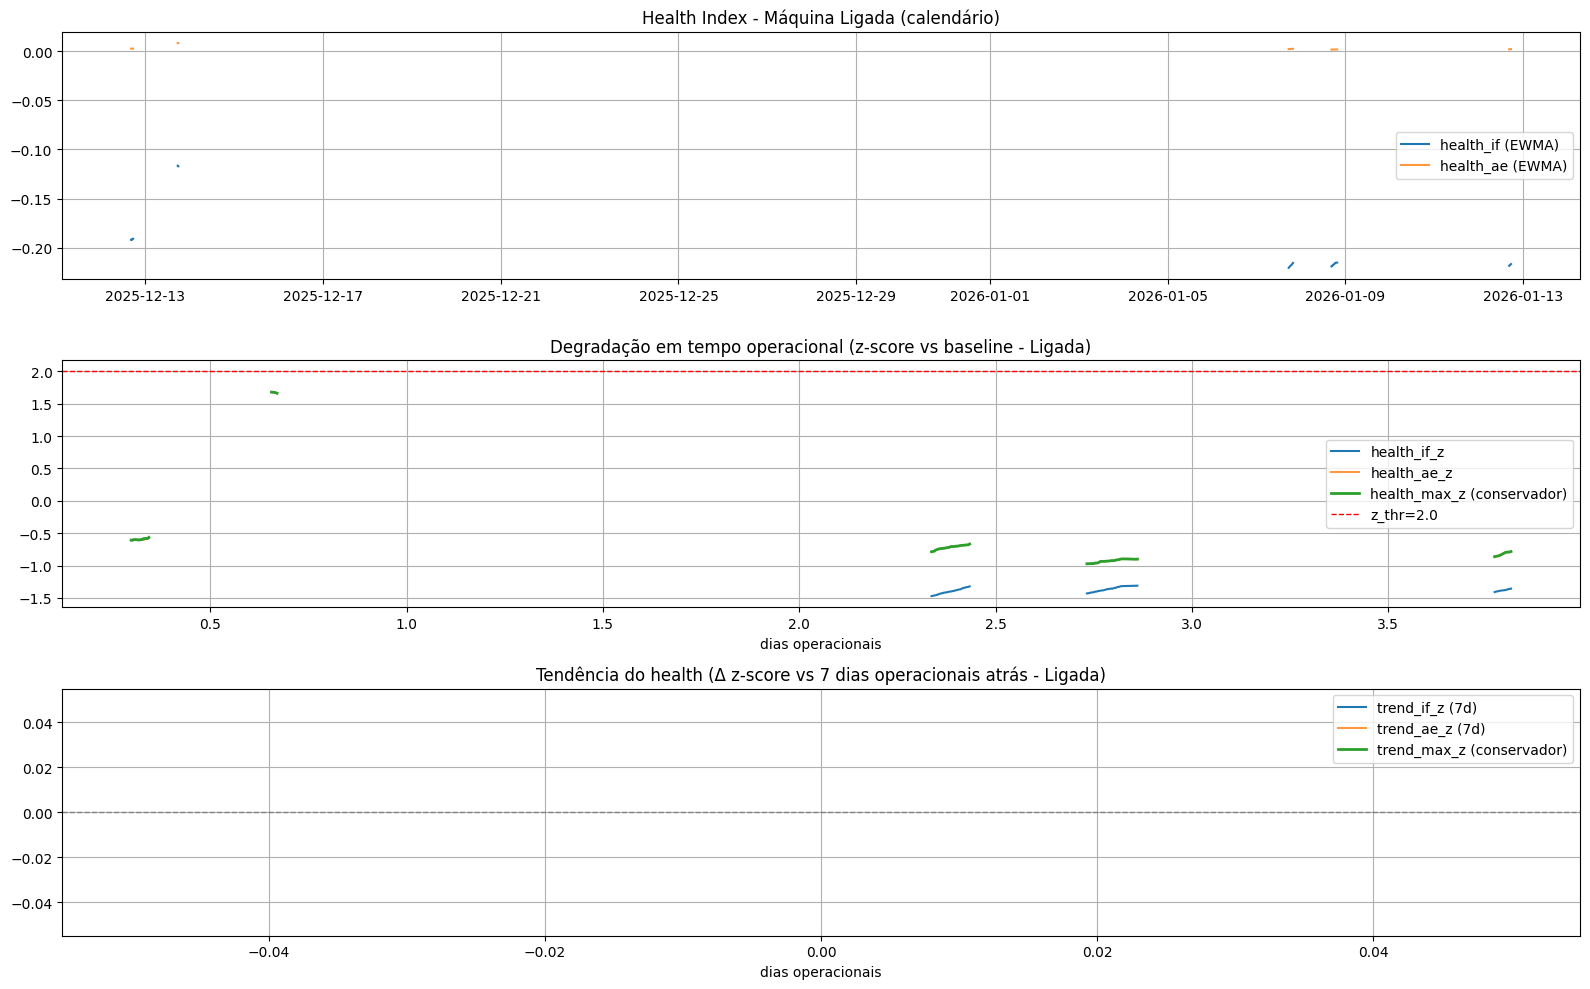

,time,segment_id,score_if,score_ae,health_if,health_ae,active_hours,active_days,health_if_z,health_ae_z,trend_if_z,trend_ae_z,health_max_z,trend_max_z
1173,2026-01-12 15:50:00,95,-0.164861,0.003055,NaN,NaN,89.916667,3.746528,NaN,NaN,NaN,NaN,NaN,NaN
1174,2026-01-12 15:55:00,95,-0.182318,0.001382,NaN,NaN,90.000000,3.750000,NaN,NaN,NaN,NaN,NaN,NaN
1175,2026-01-12 16:00:00,95,-0.170458,0.005238,NaN,NaN,90.083333,3.753472,NaN,NaN,NaN,NaN,NaN,NaN
1176,2026-01-12 16:05:00,95,-0.141283,0.010841,NaN,NaN,90.166667,3.756944,NaN,NaN,NaN,NaN,NaN,NaN
1177,2026-01-12 16:10:00,95,-0.144696,0.010097,NaN,NaN,90.250000,3.760417,NaN,NaN,NaN,NaN,NaN,NaN
1178,2026-01-12 16:15:00,95,-0.101908,0.005227,NaN,NaN,90.333333,3.763889,NaN,NaN,NaN,NaN,NaN,NaN
1179,2026-01-12 16:20:00,95,-0.143749,0.003206,NaN,NaN,90.416667,3.767361,NaN,NaN,NaN,NaN,NaN,NaN
1180,2026-01-12 16:25:00,95,-0.155255,0.003380,-0.218211,0.001745,90.500000,3.770833,-1.410801,-0.863819,NaN,NaN,-0.863819,NaN
1181,2026-01-12 16:30:00,95,-0.115606,0.009255,-0.217973,0.001762,90.583333,3.774306,-1.403591,-0.856847,NaN,NaN,-0.856847,NaN
1182,2026-01-12 16:35:00,95,-0.165505,0.003128,-0.217852,0.001765,90.666667,3.777778,-1.399904,-0.855579,NaN,NaN,-0.855579,NaN


In [36]:
# Requer: df_scored (IF) e df_scored_ae (AE) já calculados acima.

if "df_scored" not in globals() or "df_scored_ae" not in globals():
    raise RuntimeError("Rode primeiro as seções de IsolationForest e Autoencoder para gerar df_scored e df_scored_ae.")

# 1) Base: alinhar scores no mesmo timestamp
df_if = df_scored[["time", "anomaly_score"]].rename(columns={"anomaly_score": "score_if"}).copy()
df_ae = df_scored_ae[["time", "anomaly_score"]].rename(columns={"anomaly_score": "score_ae"}).copy()

df_health_raw = (
    df_if.merge(df_ae, on="time", how="inner")
    .sort_values("time")
    .reset_index(drop=True)
 )

# 2) Frequência aproximada + downtime
t_raw = pd.to_datetime(df_health_raw["time"]).sort_values()
dt_raw = t_raw.diff().dropna()
if dt_raw.empty:
    raise RuntimeError("Poucos dados para calcular tendência.")

median_step = dt_raw.median()
median_step = median_step if pd.notna(median_step) and median_step > pd.Timedelta(0) else pd.Timedelta(minutes=1)
step_min = int(max(1, round(median_step / pd.Timedelta(minutes=1))))
freq = f"{step_min}min"

# downtime quando gap > 2x passo mediano (ajuste se precisar)
downtime_gap = max(2 * median_step, pd.Timedelta(minutes=step_min * 3))
seg_id = (t_raw.diff().isna() | (t_raw.diff() > downtime_gap)).cumsum().astype(int)
df_health_raw["segment_id"] = seg_id.values

print(f"Frequência estimada: {freq} | passo mediano: {median_step} | downtime_gap: {downtime_gap}")
print("Segmentos (por downtime):", int(df_health_raw["segment_id"].nunique()))

# 3) Health Index (EWMA) por segmento (sem atravessar downtime)
samples_per_day = int(max(10, round(pd.Timedelta(days=1) / pd.to_timedelta(freq))))
health_span_days = 3  # suavização (dias ativos)
trend_days = 7        # janela de tendência (dias ativos)
min_baseline_days = 3 # baseline inicial (dias ativos)

span_health = int(max(10, samples_per_day * health_span_days))
shift_trend = int(max(1, samples_per_day * trend_days))
ffill_limit = 3  # preencher pequenos buracos dentro do segmento (0 = não preencher)

rows = []
for sid, g in df_health_raw.groupby("segment_id", sort=True):
    g = g.copy().sort_values("time")
    g = g.set_index(pd.to_datetime(g["time"]))[["score_if", "score_ae"]]
    g = g.resample(freq).mean()
    if ffill_limit and ffill_limit > 0:
        g[["score_if", "score_ae"]] = g[["score_if", "score_ae"]].ffill(limit=int(ffill_limit))

    health_if = g["score_if"].ewm(span=span_health, adjust=False, min_periods=max(5, span_health // 10)).mean()
    health_ae = g["score_ae"].ewm(span=span_health, adjust=False, min_periods=max(5, span_health // 10)).mean()

    out = pd.DataFrame({
        "time": g.index,
        "segment_id": sid,
        "score_if": g["score_if"].values,
        "score_ae": g["score_ae"].values,
        "health_if": health_if.values,
        "health_ae": health_ae.values,
    })
    rows.append(out)

df_health = pd.concat(rows, ignore_index=True)
df_health = df_health.sort_values("time").reset_index(drop=True)

# 4) Tempo operacional acumulado (já estamos usando apenas dados ligados)
# Como os dados já são apenas da máquina ligada, todos os intervalos são tempo real de operação
t = pd.to_datetime(df_health["time"])
dt = t.diff()
# Considera apenas gaps razoáveis (< downtime_gap) como tempo operacional contínuo
active_dt = dt.where((dt.notna()) & (dt <= downtime_gap), pd.Timedelta(0))
df_health["active_hours"] = active_dt.dt.total_seconds().fillna(0).cumsum() / 3600.0
df_health["active_days"] = df_health["active_hours"] / 24.0

# 5) Z-score vs baseline inicial (referência do “quão pior que o início”)
baseline_end = df_health["time"].min() + pd.Timedelta(days=min_baseline_days)
baseline = df_health[df_health["time"] <= baseline_end].copy()

def _safe_mean_std(s: pd.Series):
    s = pd.to_numeric(s, errors="coerce").dropna()
    if len(s) < 10:
        return float(s.mean()) if len(s) else np.nan, float(s.std(ddof=0)) if len(s) else np.nan
    return float(s.mean()), float(s.std(ddof=0))

mu_if, sd_if = _safe_mean_std(baseline["health_if"])
mu_ae, sd_ae = _safe_mean_std(baseline["health_ae"])
sd_if = sd_if if (sd_if is not None and sd_if > 1e-12) else np.nan
sd_ae = sd_ae if (sd_ae is not None and sd_ae > 1e-12) else np.nan

df_health["health_if_z"] = (df_health["health_if"] - mu_if) / sd_if
df_health["health_ae_z"] = (df_health["health_ae"] - mu_ae) / sd_ae

# 6) Tendência em z-score (comparável entre modelos)
df_health["trend_if_z"] = df_health["health_if_z"] - df_health["health_if_z"].shift(shift_trend)
df_health["trend_ae_z"] = df_health["health_ae_z"] - df_health["health_ae_z"].shift(shift_trend)

# Combinações conservadoras (pior caso), sem warnings de NaN
df_health["health_max_z"] = df_health[["health_if_z", "health_ae_z"]].max(axis=1, skipna=True)
df_health["trend_max_z"] = df_health[["trend_if_z", "trend_ae_z"]].max(axis=1, skipna=True)

# 7) Qual modelo está melhor para acompanhar degradação aqui?
valid = df_health.dropna(subset=["active_hours", "health_if_z", "health_ae_z"]).copy()
if len(valid) > 20:
    spearman_if = float(valid[["active_hours", "health_if_z"]].corr(method="spearman").iloc[0, 1])
    spearman_ae = float(valid[["active_hours", "health_ae_z"]].corr(method="spearman").iloc[0, 1])
else:
    spearman_if = np.nan
    spearman_ae = np.nan

best_model = "AE" if (pd.notna(spearman_ae) and (pd.isna(spearman_if) or spearman_ae >= spearman_if)) else "IF"
print("\nMonotonicidade (Spearman vs tempo ativo) do health_z:")
print(f"  IF: {spearman_if:.3f}")
print(f"  AE: {spearman_ae:.3f}")
print(f"  Melhor para tendência (neste dataset): {best_model}")

last = df_health.dropna(subset=["health_max_z"]).tail(1)
if len(last):
    print("\nEstado atual (último ponto):")
    print(f"  time:         {last['time'].iloc[0]}")
    print(f"  active_days:  {float(last['active_days'].iloc[0]):.2f}")
    print(f"  health_if_z:  {float(last['health_if_z'].iloc[0]):.2f}")
    print(f"  health_ae_z:  {float(last['health_ae_z'].iloc[0]):.2f}")
    print(f"  health_max_z: {float(last['health_max_z'].iloc[0]):.2f} (conservador)")

# 8) Plots: calendário vs tempo ativo (para ver degradação sem downtime)
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=False)

# (A) calendário (apenas dados ligados)
axes[0].plot(df_health["time"], df_health["health_if"], label="health_if (EWMA)")
axes[0].plot(df_health["time"], df_health["health_ae"], label="health_ae (EWMA)", alpha=0.8)
axes[0].set_title("Health Index - Máquina Ligada (calendário)")
axes[0].grid(True)
axes[0].legend()

# (B) degradação em tempo ativo (z-score)
axes[1].plot(df_health["active_days"], df_health["health_if_z"], label="health_if_z")
axes[1].plot(df_health["active_days"], df_health["health_ae_z"], label="health_ae_z", alpha=0.8)
axes[1].plot(df_health["active_days"], df_health["health_max_z"], label="health_max_z (conservador)", linewidth=2)
z_thr = 2.0
axes[1].axhline(z_thr, color="red", linestyle="--", linewidth=1, label=f"z_thr={z_thr}")
axes[1].set_title("Degradação em tempo operacional (z-score vs baseline - Ligada)")
axes[1].set_xlabel("dias operacionais")
axes[1].grid(True)
axes[1].legend()

# (C) tendência em tempo ativo (delta z vs 7 dias ativos atrás)
axes[2].plot(df_health["active_days"], df_health["trend_if_z"], label=f"trend_if_z ({trend_days}d)")
axes[2].plot(df_health["active_days"], df_health["trend_ae_z"], label=f"trend_ae_z ({trend_days}d)", alpha=0.8)
axes[2].plot(df_health["active_days"], df_health["trend_max_z"], label="trend_max_z (conservador)", linewidth=2)
axes[2].axhline(0.0, color="gray", linestyle="--", linewidth=1)
axes[2].set_title(f"Tendência do health (Δ z-score vs {trend_days} dias operacionais atrás - Ligada)")
axes[2].set_xlabel("dias operacionais")
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

display(df_health.tail(20))

# Análise de tendência - RMS e Médias ao longo do tempo (Ligada)
Para visualizar melhor se os níveis de vibração estão aumentando, vamos plotar diretamente as métricas RMS e médias ao longo do tempo operacional.

Velocidade - RMS: ['meanxrms', 'meanyrms', 'meanzrms']
Velocidade - Mean: ['meanxrms', 'meanyrms', 'meanzrms']
Aceleração - RMS: ['meanxrms', 'meanyrms', 'meanzrms']
Aceleração - Mean: ['meanxrms', 'meanyrms', 'meanzrms']


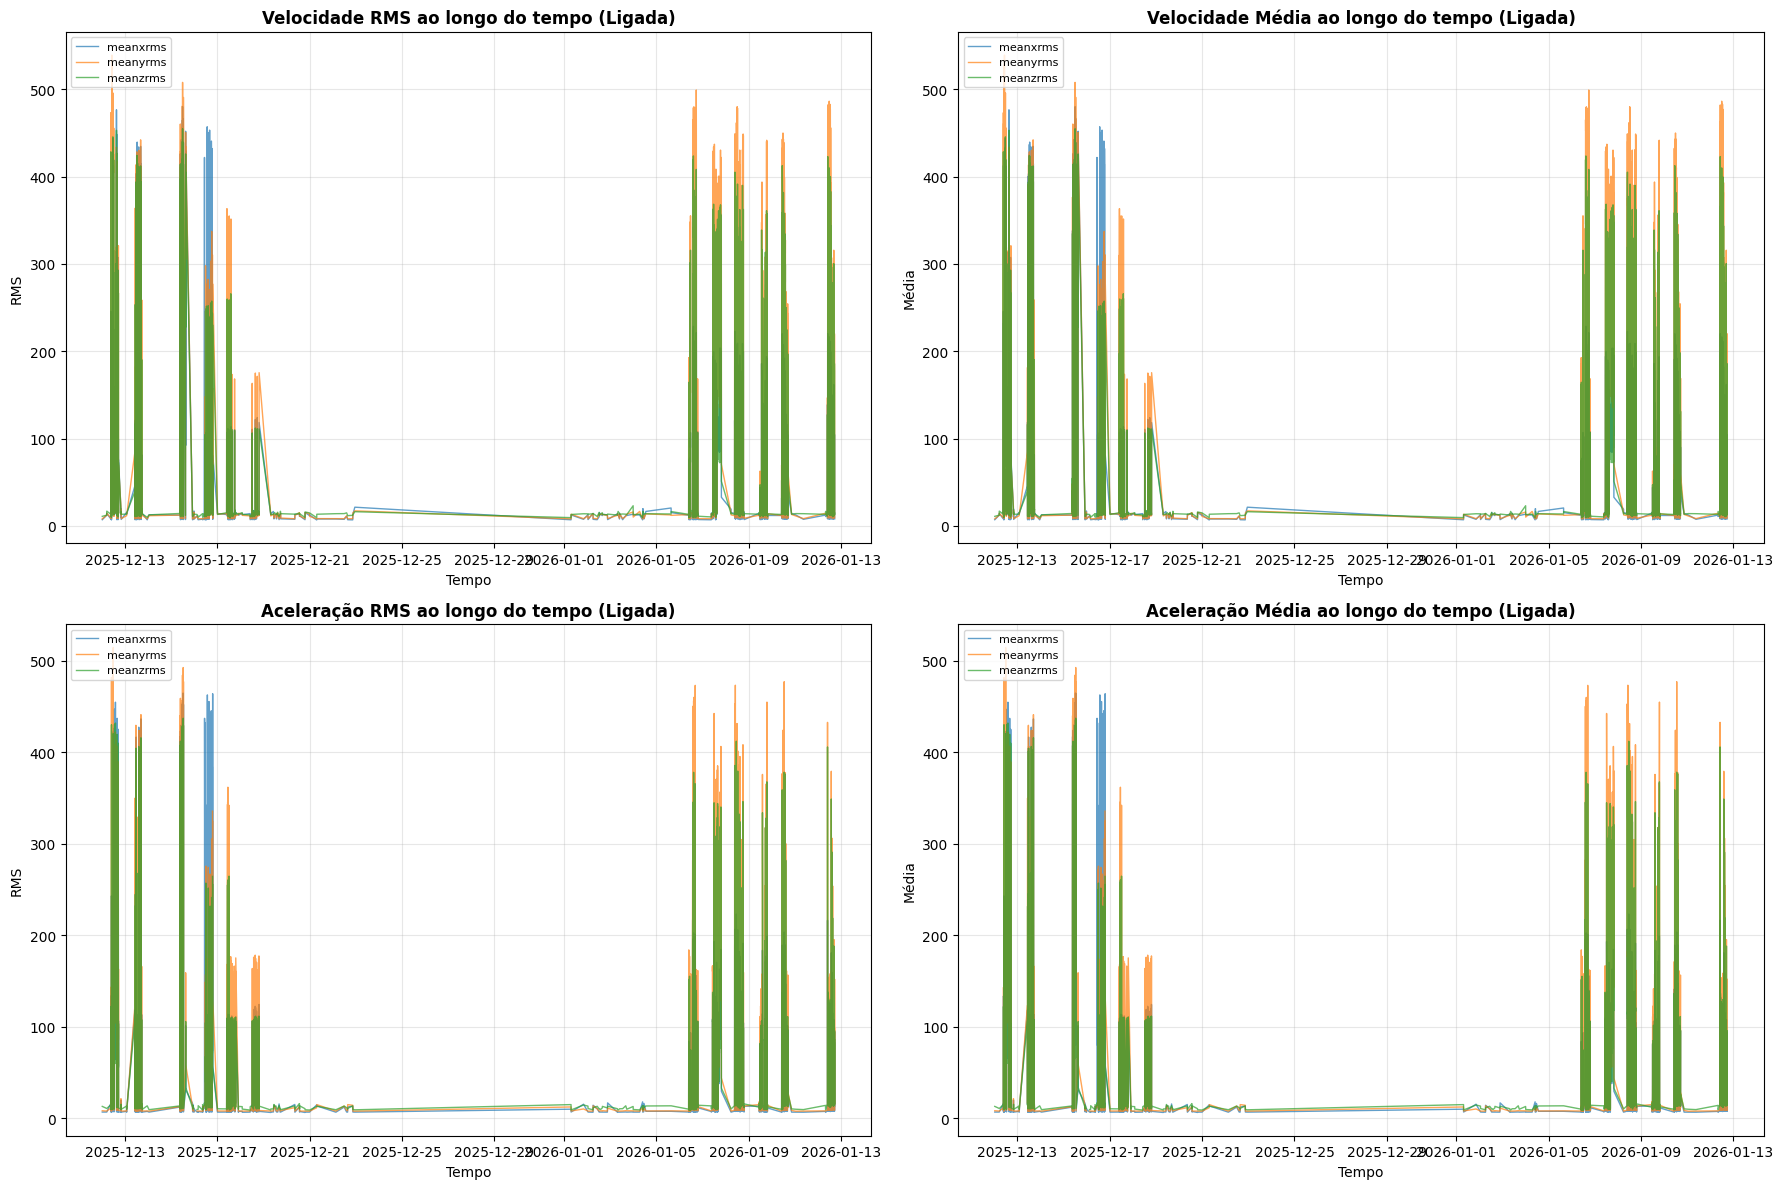


=== Análise de tendência (primeira metade vs segunda metade) ===
Vel meanxrms: 1ª metade=85.12, 2ª metade=74.83, Δ=-12.1%
Vel meanyrms: 1ª metade=126.16, 2ª metade=163.23, Δ=+29.4%
Vel meanzrms: 1ª metade=102.95, 2ª metade=138.71, Δ=+34.7%
Acc meanxrms: 1ª metade=80.16, 2ª metade=71.52, Δ=-10.8%
Acc meanyrms: 1ª metade=107.33, 2ª metade=114.05, Δ=+6.3%
Acc meanzrms: 1ª metade=79.68, 2ª metade=89.16, Δ=+11.9%


In [37]:
# Identificar colunas RMS e Mean
vel_rms_cols = [c for c in df_vel_m3_on.columns if 'rms' in c.lower() and c not in ['time', 'is_on']]
vel_mean_cols = [c for c in df_vel_m3_on.columns if 'mean' in c.lower() and c not in ['time', 'is_on']]
acc_rms_cols = [c for c in df_acc_m3_on.columns if 'rms' in c.lower() and c not in ['time', 'is_on']]
acc_mean_cols = [c for c in df_acc_m3_on.columns if 'mean' in c.lower() and c not in ['time', 'is_on']]

print(f"Velocidade - RMS: {vel_rms_cols}")
print(f"Velocidade - Mean: {vel_mean_cols}")
print(f"Aceleração - RMS: {acc_rms_cols}")
print(f"Aceleração - Mean: {acc_mean_cols}")

# Criar figura com 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Velocidade RMS
ax_vel_rms = axes[0, 0]
for col in vel_rms_cols:
    ax_vel_rms.plot(df_vel_m3_on['time'], df_vel_m3_on[col], label=col, linewidth=1, alpha=0.7)
ax_vel_rms.set_title('Velocidade RMS ao longo do tempo (Ligada)', fontsize=12, fontweight='bold')
ax_vel_rms.set_xlabel('Tempo')
ax_vel_rms.set_ylabel('RMS')
ax_vel_rms.legend(loc='upper left', fontsize=8)
ax_vel_rms.grid(True, alpha=0.3)

# Velocidade Mean
ax_vel_mean = axes[0, 1]
for col in vel_mean_cols:
    ax_vel_mean.plot(df_vel_m3_on['time'], df_vel_m3_on[col], label=col, linewidth=1, alpha=0.7)
ax_vel_mean.set_title('Velocidade Média ao longo do tempo (Ligada)', fontsize=12, fontweight='bold')
ax_vel_mean.set_xlabel('Tempo')
ax_vel_mean.set_ylabel('Média')
ax_vel_mean.legend(loc='upper left', fontsize=8)
ax_vel_mean.grid(True, alpha=0.3)

# Aceleração RMS
ax_acc_rms = axes[1, 0]
for col in acc_rms_cols:
    ax_acc_rms.plot(df_acc_m3_on['time'], df_acc_m3_on[col], label=col, linewidth=1, alpha=0.7)
ax_acc_rms.set_title('Aceleração RMS ao longo do tempo (Ligada)', fontsize=12, fontweight='bold')
ax_acc_rms.set_xlabel('Tempo')
ax_acc_rms.set_ylabel('RMS')
ax_acc_rms.legend(loc='upper left', fontsize=8)
ax_acc_rms.grid(True, alpha=0.3)

# Aceleração Mean
ax_acc_mean = axes[1, 1]
for col in acc_mean_cols:
    ax_acc_mean.plot(df_acc_m3_on['time'], df_acc_m3_on[col], label=col, linewidth=1, alpha=0.7)
ax_acc_mean.set_title('Aceleração Média ao longo do tempo (Ligada)', fontsize=12, fontweight='bold')
ax_acc_mean.set_xlabel('Tempo')
ax_acc_mean.set_ylabel('Média')
ax_acc_mean.legend(loc='upper left', fontsize=8)
ax_acc_mean.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estatísticas de tendência simples (primeira metade vs segunda metade)
midpoint = len(df_vel_m3_on) // 2
print("\n=== Análise de tendência (primeira metade vs segunda metade) ===")

for col in vel_rms_cols[:3]:  # Top 3 colunas
    first_half = df_vel_m3_on[col].iloc[:midpoint].mean()
    second_half = df_vel_m3_on[col].iloc[midpoint:].mean()
    pct_change = ((second_half - first_half) / first_half) * 100 if first_half > 0 else 0
    print(f"Vel {col}: 1ª metade={first_half:.2f}, 2ª metade={second_half:.2f}, Δ={pct_change:+.1f}%")

for col in acc_rms_cols[:3]:  # Top 3 colunas
    first_half = df_acc_m3_on[col].iloc[:midpoint].mean()
    second_half = df_acc_m3_on[col].iloc[midpoint:].mean()
    pct_change = ((second_half - first_half) / first_half) * 100 if first_half > 0 else 0
    print(f"Acc {col}: 1ª metade={first_half:.2f}, 2ª metade={second_half:.2f}, Δ={pct_change:+.1f}%")

# Temperatura vs Alertas

Vamos verificar se a **temperatura** (nas colunas `*temp*`) está correlacionada com os **picos de alerta** dos modelos (IsolationForest e Autoencoder).

A análise vai responder:
- A temperatura média nos alertas é maior que a baseline geral?
- Temperatura antecede os alertas (sobe antes)?
- Qual a correlação temporal entre temperatura e anomaly score?

Colunas de temperatura: ['vel_maxtemp', 'acc_maxtemp']

Baseline de temperatura (dataset completo):


,mean,std,p50,p95
vel_maxtemp,24.075386,4.973817,24.0,31.0
acc_maxtemp,24.326975,5.039326,24.0,32.0



Temperatura nos alertas vs baseline:


,temp_col,label,n_alerts,mean_at_alert,std_at_alert,baseline_mean,baseline_std,delta_mean,z_score
1,acc_maxtemp,IF_warning,2,26.5,3.5,24.326975,5.039326,2.173025,0.431213
0,vel_maxtemp,IF_warning,2,28.5,2.5,24.075386,4.973817,4.424614,0.889581



Correlação (Spearman) temperatura vs anomaly_score:


,temp_col,corr_IF,corr_AE
0,vel_maxtemp,0.106100,0.245686
1,acc_maxtemp,0.068609,0.245652


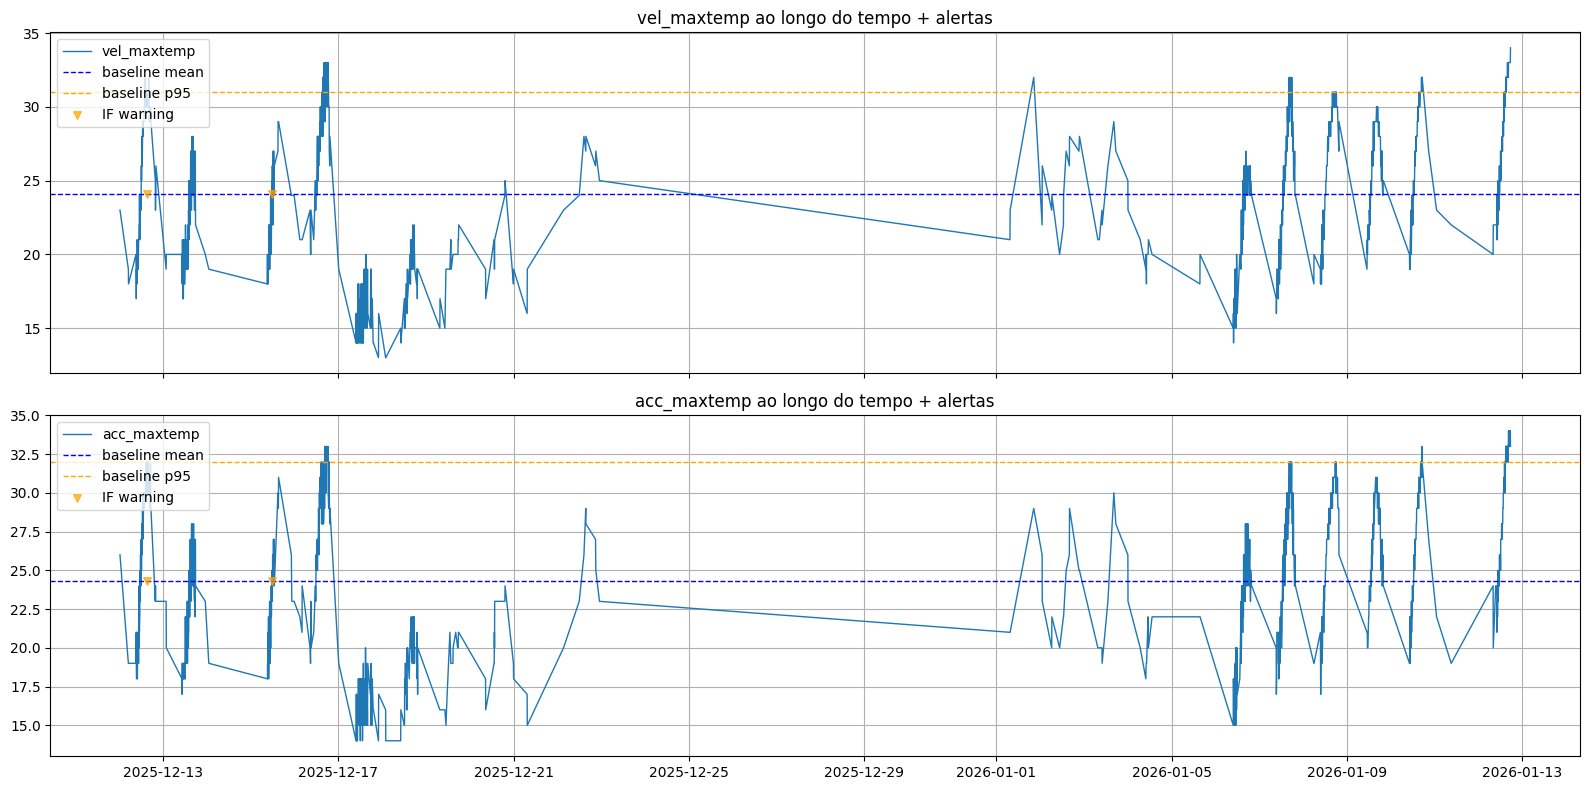

In [34]:
# Requer: df_scored, alerts_warning, alerts_critical (IF) e df_scored_ae, alerts_*_ae (AE)

if "df_scored" not in globals() or "alerts_warning" not in globals():
    raise RuntimeError("Rode primeiro as seções de anomalia e alertas.")

# 1) Identificar colunas de temperatura
temp_cols = [c for c in df_scored.columns if "temp" in c.lower() and c != "time"]
if not temp_cols:
    print("Nenhuma coluna de temperatura encontrada no dataset.")
else:
    print(f"Colunas de temperatura: {temp_cols}")
    
    # 2) Baseline geral de temperatura (média e desvio padrão)
    temp_baseline = {}
    for tc in temp_cols:
        vals = pd.to_numeric(df_scored[tc], errors="coerce").dropna()
        if len(vals) > 10:
            temp_baseline[tc] = {
                "mean": float(vals.mean()),
                "std": float(vals.std()),
                "p50": float(vals.quantile(0.50)),
                "p95": float(vals.quantile(0.95)),
            }
    
    print("\nBaseline de temperatura (dataset completo):")
    display(pd.DataFrame(temp_baseline).T)
    
    # 3) Temperatura nos alertas vs baseline
    def temp_at_alerts(alerts_df: pd.DataFrame, df_data: pd.DataFrame, label: str):
        if alerts_df is None or alerts_df.empty or len(alerts_df) == 0:
            return None
        peak_times = list(pd.to_datetime(alerts_df["peak_time"]))
        rows = []
        for tc in temp_cols:
            vals_at_alerts = []
            for pt in peak_times:
                match = df_data.loc[df_data["time"] == pt, tc]
                if len(match):
                    vals_at_alerts.append(float(match.iloc[0]))
            if vals_at_alerts:
                vals_arr = np.array(vals_at_alerts)
                bl = temp_baseline.get(tc, {})
                rows.append({
                    "temp_col": tc,
                    "label": label,
                    "n_alerts": len(vals_at_alerts),
                    "mean_at_alert": float(np.mean(vals_arr)),
                    "std_at_alert": float(np.std(vals_arr)),
                    "baseline_mean": bl.get("mean", np.nan),
                    "baseline_std": bl.get("std", np.nan),
                    "delta_mean": float(np.mean(vals_arr) - bl.get("mean", np.nan)),
                    "z_score": float((np.mean(vals_arr) - bl.get("mean", np.nan)) / bl.get("std", 1e-9)) if bl.get("std", 0) > 1e-9 else np.nan,
                })
        return pd.DataFrame(rows) if rows else None
    
    temp_if_crit = temp_at_alerts(alerts_critical, df_scored, "IF_critical")
    temp_if_warn = temp_at_alerts(alerts_warning, df_scored, "IF_warning")
    temp_ae_crit = temp_at_alerts(alerts_critical_ae, df_scored_ae, "AE_critical")
    temp_ae_warn = temp_at_alerts(alerts_warning_ae, df_scored_ae, "AE_warning")
    
    temp_summary = pd.concat([temp_if_crit, temp_if_warn, temp_ae_crit, temp_ae_warn], ignore_index=True)
    if len(temp_summary):
        print("\nTemperatura nos alertas vs baseline:")
        display(temp_summary.sort_values(["temp_col", "label"]))
    
    # 4) Correlação temporal: temperatura x anomaly_score
    print("\nCorrelação (Spearman) temperatura vs anomaly_score:")
    corr_rows = []
    for tc in temp_cols:
        # IF
        valid_if = df_scored[[tc, "anomaly_score"]].dropna()
        if len(valid_if) > 20:
            corr_if = float(valid_if.corr(method="spearman").iloc[0, 1])
        else:
            corr_if = np.nan
        # AE
        valid_ae = df_scored_ae[[tc, "anomaly_score"]].dropna()
        if len(valid_ae) > 20:
            corr_ae = float(valid_ae.corr(method="spearman").iloc[0, 1])
        else:
            corr_ae = np.nan
        corr_rows.append({
            "temp_col": tc,
            "corr_IF": corr_if,
            "corr_AE": corr_ae,
        })
    display(pd.DataFrame(corr_rows))
    
    # 5) Gráficos: temperatura + alertas ao longo do tempo
    fig, axes = plt.subplots(len(temp_cols), 1, figsize=(16, 4 * len(temp_cols)), sharex=True)
    if len(temp_cols) == 1:
        axes = [axes]
    
    for i, tc in enumerate(temp_cols):
        axes[i].plot(df_scored["time"], df_scored[tc], label=tc, linewidth=1)
        bl = temp_baseline.get(tc, {})
        if "mean" in bl:
            axes[i].axhline(bl["mean"], color="blue", linestyle="--", linewidth=1, label="baseline mean")
        if "p95" in bl:
            axes[i].axhline(bl["p95"], color="orange", linestyle="--", linewidth=1, label="baseline p95")
        
        # Marca os alertas
        if len(alerts_critical):
            axes[i].scatter(alerts_critical["peak_time"], 
                           [bl.get("p95", bl.get("mean", 50))] * len(alerts_critical),
                           color="red", s=50, marker="v", label="IF critical", zorder=5)
        if len(alerts_warning):
            axes[i].scatter(alerts_warning["peak_time"],
                           [bl.get("mean", 50)] * len(alerts_warning),
                           color="orange", s=30, marker="v", label="IF warning", alpha=0.7, zorder=4)
        
        axes[i].set_title(f"{tc} ao longo do tempo + alertas")
        axes[i].grid(True)
        axes[i].legend(loc="upper left")
    
    plt.tight_layout()
    plt.show()
    
    # 6) Janela ao redor de alertas críticos: temperatura antecede?
    if len(alerts_critical) and len(temp_cols):
        print("\nJanela ±60 min ao redor dos alertas críticos (IF) - temperatura antecede?")
        for idx in range(min(3, len(alerts_critical))):  # limita a 3 eventos
            peak = pd.to_datetime(alerts_critical.iloc[idx]["peak_time"])
            start = peak - pd.Timedelta(minutes=60)
            end = peak + pd.Timedelta(minutes=60)
            window = df_scored[(df_scored["time"] >= start) & (df_scored["time"] <= end)].copy()
            if window.empty:
                continue
            
            fig, ax1 = plt.subplots(figsize=(16, 5))
            ax1.plot(window["time"], window["anomaly_score"], color="black", linewidth=2, label="anomaly_score")
            ax1.axvline(peak, color="red", linestyle="--", linewidth=1, label="peak alerta")
            ax1.set_ylabel("anomaly_score")
            ax1.grid(True)
            
            ax2 = ax1.twinx()
            for tc in temp_cols:
                ax2.plot(window["time"], window[tc], linewidth=2, alpha=0.8, label=tc)
            ax2.set_ylabel("temperatura")
            
            lines, labels = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax1.legend(lines + lines2, labels + labels2, loc="upper left")
            plt.title(f"Janela alerta crítico #{idx+1} | peak={peak}")
            plt.show()

# Reconstrução de forma de onda (aproximada)

Como o dataset contém **estatísticas agregadas** (mean, RMS, max) por minuto e não amostras brutas em alta frequência, vamos **sintetizar formas de onda aproximadas** usando essas estatísticas.

A reconstrução usa:
- **RMS**: amplitude da senoide (energia da vibração)
- **mean**: offset DC (componente estática)
- **max**: limita os picos (clipping realista)

Isso dá uma **noção visual** de como a vibração estava se comportando ao longo do tempo.

Aceleração: 3 canais RMS, 3 mean, 3 max
Velocidade: 3 canais RMS, 3 mean, 3 max

Timestamps selecionados para reconstrução: 5


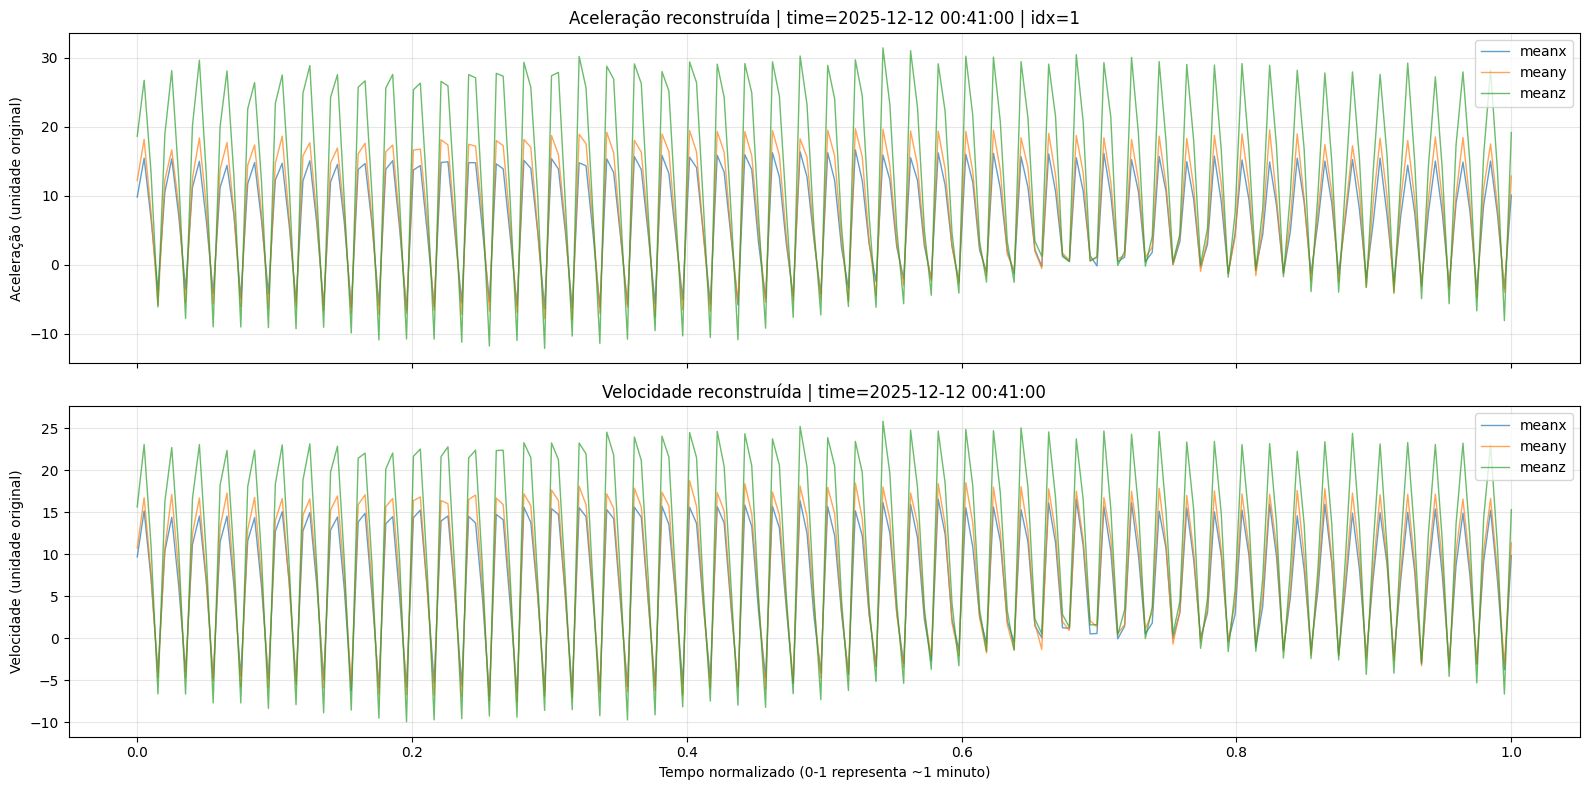

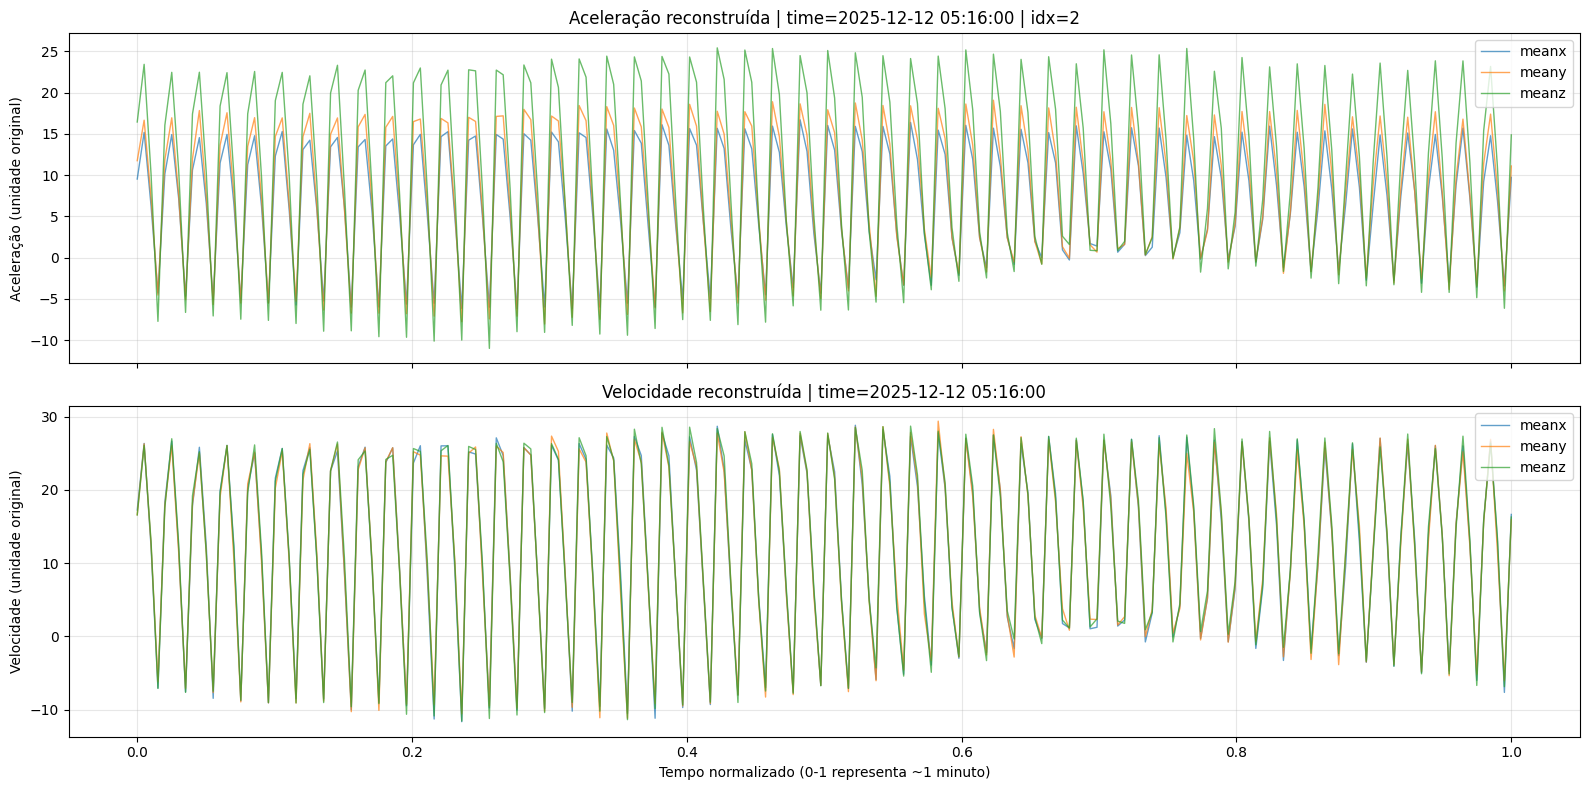

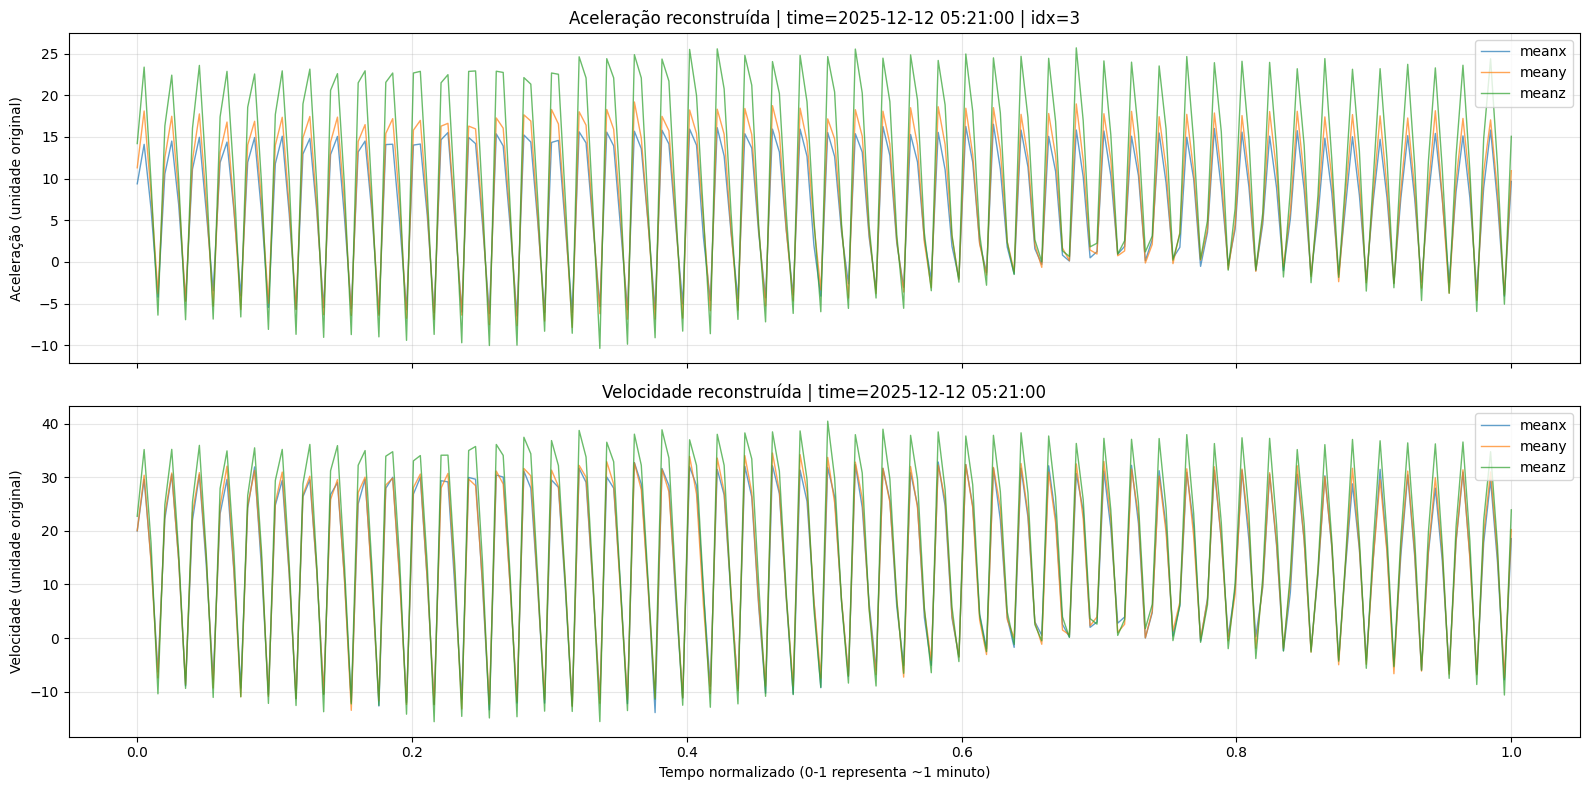

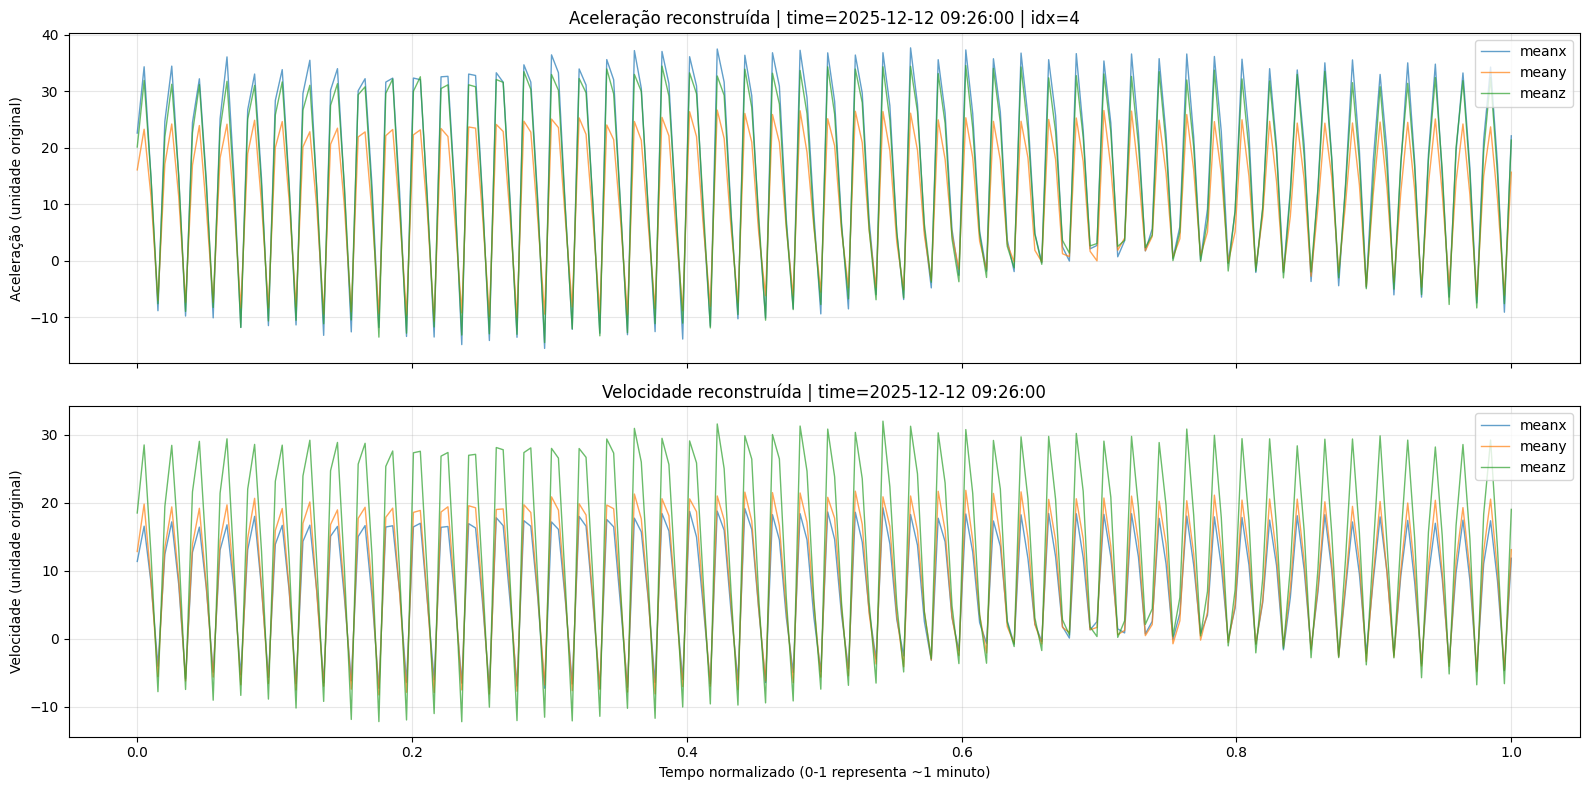

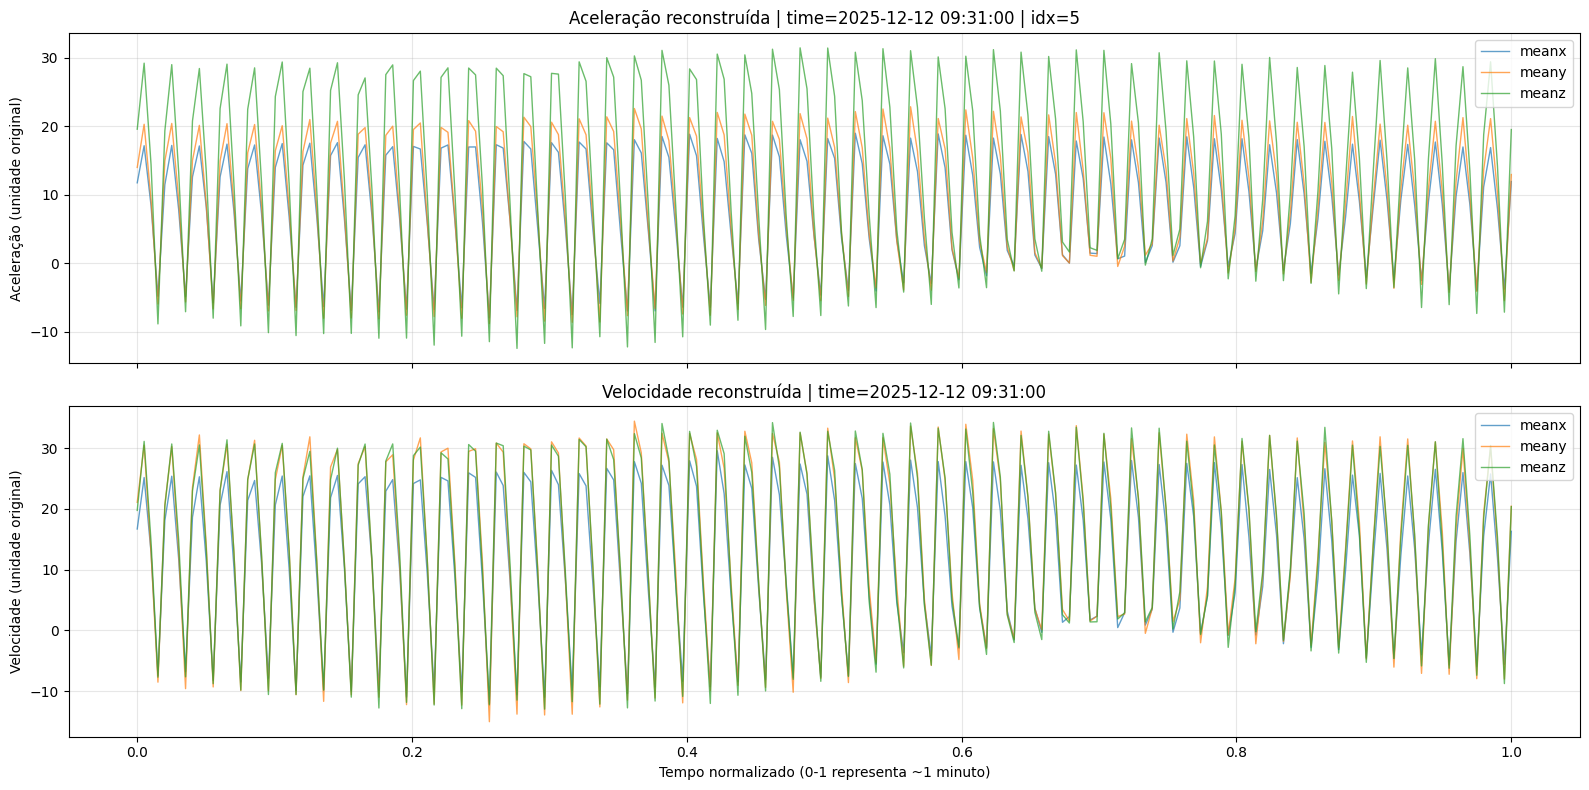


--- Comparação: Baseline vs Alerta crítico ---


In [35]:
# Requer: df_model (com todas as features vel_*/acc_*)

if "df_model" not in globals():
    raise RuntimeError("Rode primeiro a seção de construção do dataset (df_model).")

# 1) Identificar colunas de RMS, mean, max para aceleração e velocidade
acc_rms_cols = [c for c in df_model.columns if c.startswith("acc_") and "rms" in c.lower()]
acc_mean_cols = [c for c in df_model.columns if c.startswith("acc_") and "mean" in c.lower()]
acc_max_cols = [c for c in df_model.columns if c.startswith("acc_") and "max" in c.lower() and "temp" not in c.lower()]

vel_rms_cols = [c for c in df_model.columns if c.startswith("vel_") and "rms" in c.lower()]
vel_mean_cols = [c for c in df_model.columns if c.startswith("vel_") and "mean" in c.lower()]
vel_max_cols = [c for c in df_model.columns if c.startswith("vel_") and "max" in c.lower() and "temp" not in c.lower()]

print(f"Aceleração: {len(acc_rms_cols)} canais RMS, {len(acc_mean_cols)} mean, {len(acc_max_cols)} max")
print(f"Velocidade: {len(vel_rms_cols)} canais RMS, {len(vel_mean_cols)} mean, {len(vel_max_cols)} max")

# 2) Função para sintetizar forma de onda aproximada
def synthesize_waveform(rms: float, mean: float, max_val: float, n_samples: int = 200, freq_hz: float = 50.0):
    """
    Sintetiza uma forma de onda aproximada (senoide + ruído) a partir de estatísticas.
    
    - rms: amplitude RMS (energia)
    - mean: offset DC
    - max_val: limita os picos
    - n_samples: número de amostras (para 1 minuto a ~200Hz seria ~12000, mas aqui usamos menos para visualização)
    - freq_hz: frequência fundamental (Hz)
    """
    if pd.isna(rms) or pd.isna(mean) or pd.isna(max_val):
        return np.full(n_samples, np.nan)
    
    # Amplitude peak-to-peak a partir de RMS (assumindo senoide pura: A_peak = RMS * sqrt(2))
    amplitude = float(rms) * np.sqrt(2)
    
    # Gera tempo (1 minuto = 60s, mas usamos normalized time)
    t = np.linspace(0, 1, n_samples)  # normalized time 0..1
    
    # Senoide fundamental + 2 harmônicos para parecer mais "real"
    signal = (
        amplitude * np.sin(2 * np.pi * freq_hz * t)
        + 0.3 * amplitude * np.sin(2 * np.pi * freq_hz * 2 * t + 0.5)  # 2nd harmonic
        + 0.15 * amplitude * np.sin(2 * np.pi * freq_hz * 3 * t + 1.2)  # 3rd harmonic
    )
    
    # Adiciona offset DC (mean)
    signal += float(mean)
    
    # Adiciona ruído gaussiano pequeno (5% do RMS)
    noise = np.random.normal(0, float(rms) * 0.05, n_samples)
    signal += noise
    
    # Clipping realista pelos max observados (limita picos)
    signal = np.clip(signal, -abs(float(max_val)), abs(float(max_val)))
    
    return signal

# 3) Selecionar alguns timestamps para visualização (incluindo alertas)
timestamps_to_plot = []

# Pega alguns timestamps normais (baseline)
normal_sample = df_model.head(5)
timestamps_to_plot.extend(list(normal_sample["time"]))

# Pega timestamps de alertas críticos (se houver)
if len(alerts_critical):
    for t in alerts_critical.head(3)["peak_time"]:
        match = df_model[df_model["time"] == t]
        if len(match):
            timestamps_to_plot.append(t)

print(f"\nTimestamps selecionados para reconstrução: {len(timestamps_to_plot)}")

# 4) Reconstrói e plota formas de onda para esses timestamps
n_samples = 200  # amostras por "forma de onda reconstruída"
freq_hz = 50.0   # frequência fundamental (ajuste se souber a real)

for idx, ts in enumerate(timestamps_to_plot[:6]):  # limita a 6 gráficos
    row = df_model[df_model["time"] == ts]
    if row.empty:
        continue
    row = row.iloc[0]
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    
    # Aceleração: reconstrói para cada canal e plota
    ax_acc = axes[0]
    for i, (rms_col, mean_col, max_col) in enumerate(zip(acc_rms_cols, acc_mean_cols, acc_max_cols)):
        if i >= 3:  # limita a 3 canais para não ficar confuso
            break
        rms = row.get(rms_col, np.nan)
        mean = row.get(mean_col, np.nan)
        max_val = row.get(max_col, np.nan)
        
        waveform = synthesize_waveform(rms, mean, max_val, n_samples=n_samples, freq_hz=freq_hz)
        t_normalized = np.linspace(0, 1, n_samples)
        
        label = rms_col.replace("acc_", "").replace("rms", "")
        ax_acc.plot(t_normalized, waveform, label=label, alpha=0.7, linewidth=1)
    
    ax_acc.set_title(f"Aceleração reconstruída | time={ts} | idx={idx+1}")
    ax_acc.set_ylabel("Aceleração (unidade original)")
    ax_acc.grid(True, alpha=0.3)
    ax_acc.legend(loc="upper right")
    
    # Velocidade: reconstrói para cada canal e plota
    ax_vel = axes[1]
    for i, (rms_col, mean_col, max_col) in enumerate(zip(vel_rms_cols, vel_mean_cols, vel_max_cols)):
        if i >= 3:  # limita a 3 canais
            break
        rms = row.get(rms_col, np.nan)
        mean = row.get(mean_col, np.nan)
        max_val = row.get(max_col, np.nan)
        
        waveform = synthesize_waveform(rms, mean, max_val, n_samples=n_samples, freq_hz=freq_hz)
        t_normalized = np.linspace(0, 1, n_samples)
        
        label = rms_col.replace("vel_", "").replace("rms", "")
        ax_vel.plot(t_normalized, waveform, label=label, alpha=0.7, linewidth=1)
    
    ax_vel.set_title(f"Velocidade reconstruída | time={ts}")
    ax_vel.set_xlabel("Tempo normalizado (0-1 representa ~1 minuto)")
    ax_vel.set_ylabel("Velocidade (unidade original)")
    ax_vel.grid(True, alpha=0.3)
    ax_vel.legend(loc="upper right")
    
    plt.tight_layout()
    plt.show()

# 5) Comparação visual: forma de onda em alerta vs baseline
print("\n--- Comparação: Baseline vs Alerta crítico ---")

baseline_row = df_model.head(1).iloc[0]
if len(alerts_critical):
    alert_row = df_model[df_model["time"] == alerts_critical.iloc[0]["peak_time"]]
    if len(alert_row):
        alert_row = alert_row.iloc[0]
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 8))
        
        # Baseline - Aceleração
        ax = axes[0, 0]
        for i, (rms_col, mean_col, max_col) in enumerate(zip(acc_rms_cols[:1], acc_mean_cols[:1], acc_max_cols[:1])):
            rms = baseline_row.get(rms_col, np.nan)
            mean = baseline_row.get(mean_col, np.nan)
            max_val = baseline_row.get(max_col, np.nan)
            waveform = synthesize_waveform(rms, mean, max_val, n_samples=n_samples, freq_hz=freq_hz)
            t_normalized = np.linspace(0, 1, n_samples)
            ax.plot(t_normalized, waveform, linewidth=1.5)
        ax.set_title(f"Baseline - Aceleração | {baseline_row['time']}")
        ax.set_ylabel("Aceleração")
        ax.grid(True, alpha=0.3)
        
        # Alerta - Aceleração
        ax = axes[0, 1]
        for i, (rms_col, mean_col, max_col) in enumerate(zip(acc_rms_cols[:1], acc_mean_cols[:1], acc_max_cols[:1])):
            rms = alert_row.get(rms_col, np.nan)
            mean = alert_row.get(mean_col, np.nan)
            max_val = alert_row.get(max_col, np.nan)
            waveform = synthesize_waveform(rms, mean, max_val, n_samples=n_samples, freq_hz=freq_hz)
            t_normalized = np.linspace(0, 1, n_samples)
            ax.plot(t_normalized, waveform, linewidth=1.5, color="red")
        ax.set_title(f"Alerta Crítico - Aceleração | {alert_row['time']}")
        ax.set_ylabel("Aceleração")
        ax.grid(True, alpha=0.3)
        
        # Baseline - Velocidade
        ax = axes[1, 0]
        for i, (rms_col, mean_col, max_col) in enumerate(zip(vel_rms_cols[:1], vel_mean_cols[:1], vel_max_cols[:1])):
            rms = baseline_row.get(rms_col, np.nan)
            mean = baseline_row.get(mean_col, np.nan)
            max_val = baseline_row.get(max_col, np.nan)
            waveform = synthesize_waveform(rms, mean, max_val, n_samples=n_samples, freq_hz=freq_hz)
            t_normalized = np.linspace(0, 1, n_samples)
            ax.plot(t_normalized, waveform, linewidth=1.5)
        ax.set_title(f"Baseline - Velocidade | {baseline_row['time']}")
        ax.set_xlabel("Tempo normalizado")
        ax.set_ylabel("Velocidade")
        ax.grid(True, alpha=0.3)
        
        # Alerta - Velocidade
        ax = axes[1, 1]
        for i, (rms_col, mean_col, max_col) in enumerate(zip(vel_rms_cols[:1], vel_mean_cols[:1], vel_max_cols[:1])):
            rms = alert_row.get(rms_col, np.nan)
            mean = alert_row.get(mean_col, np.nan)
            max_val = alert_row.get(max_col, np.nan)
            waveform = synthesize_waveform(rms, mean, max_val, n_samples=n_samples, freq_hz=freq_hz)
            t_normalized = np.linspace(0, 1, n_samples)
            ax.plot(t_normalized, waveform, linewidth=1.5, color="red")
        ax.set_title(f"Alerta Crítico - Velocidade | {alert_row['time']}")
        ax.set_xlabel("Tempo normalizado")
        ax.set_ylabel("Velocidade")
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print(f"\nComparação de estatísticas (primeiro canal):")
        print(f"  Baseline RMS acc: {baseline_row.get(acc_rms_cols[0], np.nan):.4f}")
        print(f"  Alerta   RMS acc: {alert_row.get(acc_rms_cols[0], np.nan):.4f}")
        print(f"  Baseline RMS vel: {baseline_row.get(vel_rms_cols[0], np.nan):.4f}")
        print(f"  Alerta   RMS vel: {alert_row.get(vel_rms_cols[0], np.nan):.4f}")